<a href="https://colab.research.google.com/github/Daudi232/MSc_Data_Science/blob/main/theoretical_and_neural_models/weather_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Overview

This project focuses on developing and evaluating machine learning models for weather forecasting, specifically predicting temperature. The primary objectives are twofold:

1.  **Point Forecasts**: To build models capable of generating accurate single-value temperature predictions, aiming to outperform existing high-resolution (hres) baseline forecasts.
2.  **Probabilistic Forecasts**: To develop models that provide a probabilistic distribution of temperature predictions (mean and standard deviation), evaluated using the Continuous Ranked Probability Score (CRPS).

# WEEK 1

## CONFIGURATION

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Daudi232

# PATH_CODES = '/content/drive/MyDrive/Colab Notebooks/MSc Data Science/Theoretical and Neural Models/Project 1/codes-20250911/'
# PATH_DATA = '/content/drive/MyDrive/Colab Notebooks/MSc Data Science/Theoretical and Neural Models/Project 1/data-20250911/'

In [ ]:
# Daudi4ril account

PATH_CODES = '/content/drive/MyDrive/MSc Data Science/Theoretical and Neural Models/Project 1/codes/'
PATH_DATA = '/content/drive/MyDrive/MSc Data Science/Theoretical and Neural Models/Project 1/data/'
PATH_MODELS = '/content/drive/MyDrive/MSc Data Science/Theoretical and Neural Models/Project 1/models/'

### IMPORTS AND LIBRARIES

In [ ]:
!pip install hydrostats
!pip install torchview

In [ ]:
import pandas as pd
import numpy as np
import math

import os
import pickle

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import torch.nn as nn

import torch.nn.functional as F


import hydrostats.ens_metrics as em




## HELPER FUNCTIONS

### Loading Data

In [ ]:
# import pickle
# import numpy as np

def read_stdata(data_path):
    with open(data_path, 'rb') as file:
        datast = pickle.load(file)
    datast.columns = [ 'day',   'lt',  'obs', 'hres'] + [ str(i) for i in np.arange(51)]
    return datast

In [ ]:
# import pickle
# import numpy as np

def read_stdata2(data_path):
    with open(data_path, 'rb') as file:
        datast = pickle.load(file)
    return datast

### Manipulating Data

In [ ]:
def my_train_test_split(data, date = '2018-01-01'):

    '''splits the data and adds the mean column'''

    trainset = data[data['day'] < date]
    testset = data[data['day'] >= date]

    # check if data consists of ensemble columns
    cols = data.columns
    ensemble_cols = [str(i) for i in range(1, 50)]
    is_subset = all(i in cols for i in ensemble_cols)

    # add mean column
    # important since it separates the mean of the train and test sets
    if is_subset:
        trainset['mean'] = trainset.loc[:, ensemble_cols].mean(axis=1)
        testset['mean'] = testset.loc[:, ensemble_cols].mean(axis=1)

    return trainset, testset

In [ ]:
# this function is redundant if my_train_test_split is used

def add_mean_column(data):
  data['mean'] = data.loc[:,'1':'50'].mean(axis = 1)
  return data

### Data Preparation

#### for single inputs

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

# import torch
# from torch.utils.data import TensorDataset
# from torch.utils.data import DataLoader

def feature_selection_norm(data, feature_cols, train_size = 0.8):
  ''' splits the "TRAINING" data into training and validation sets,
  then extracts the relevant features and normalizes.

  returns the normalized training and validation data along with their means and std'''

  # split the entire dataset
  X_train, X_val, y_train, y_val = train_test_split(data.drop(columns = ['day', 'obs']),
                                                    data['obs'],
                                                    train_size = train_size,
                                                    random_state = 7,
                                                    shuffle = True
                                                    )

  print(f'Splitting complete\n \
        Training set size: {X_train.shape[0]}\n \
        Validation set size: {X_val.shape[0]}\n')

  # extract the columns we need
  X_train, X_val = X_train.loc[:, feature_cols], X_val.loc[:, feature_cols]

  print('Feature extraction is complete\n')
  print(f"Rows before Normalization:\n \
        {X_train.iloc[0:2,: ]}\n") # iloc is used because the splitting may have messed with the index names

  # normalize the data
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train_norm = scaler.transform(X_train)
  X_val_norm = scaler.transform(X_val)

  print('Normalization is complete\n')
  print(f"Rows after Normalization:\n \
        {X_train_norm[0:2, ]}") #standard scaler makes it a numpy array

  # the normalized values are numpy arrays
  return X_train_norm, y_train, X_val_norm, y_val, scaler.mean_, scaler.scale_


def to_data_loader(X_train, y_train, X_val, y_val, batch_size = 32):
  '''converts the normalized data into a pytorch data loader'''

  # the float() is important since numpy arrays are in float64 which conflicts with pytorchs weights in float32
  # y_train is a pandas series, so we have to convert it to numpy before making it a tensor

  train_td = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train.to_numpy()).float())
  val_td = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val.to_numpy()).float())

  print (f'Conversion to Tensor dataset is complete\n \
  Type: {type(train_td)}\n')

  train_loader = DataLoader(train_td, batch_size = batch_size, shuffle = True)
  val_loader = DataLoader(val_td, batch_size = batch_size) # no need to shuffle validation set

  features, targets = next(iter(train_loader)) # get the first batch details
  print (f'Conversion to DataLoader is complete\n \
  Feature shape per batch: {features.shape}\n \
  Target shape per batch: {targets.shape} \n \
  Total number of batches: {len(train_loader)}\n \
  Size of training set: {len(train_loader.dataset)}\n \
  Size of validation set: {len(val_loader.dataset)}')

  return train_loader, val_loader

#### for multiple inputs

no code yet

##### Pytorch custom Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset): # inherits from pytorch datasets

    def __init__(self, input1, input2, labels):
        # input1, input2, and labels should be NumPy arrays or PyTorch tensors

        self.input1 = torch.tensor(input1, dtype=torch.float32)
        self.input2 = torch.tensor(input2, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        # This returns the total number of samples
        return len(self.labels) # it is easier to use labels here since it is one-dimensional

    def __getitem__(self, idx):
        # This returns one sample from the dataset
        return self.input1[idx], self.input2[idx], self.labels[idx] # i have never checked out a sample like this but looks like this is what makes it happen

### Training

#### with single inputs

##### without checkpointing

In [ ]:
# import torch
# import torch.nn.functional as F

# import numpy as np

# import os

def train (model, train_data_loader, val_data_loader, optimizer, loss_fn, epochs = 100, device=torch.device('cpu')):

  model.to(device) # shift the model to GPU if available
  history_train = [] # for recording history of training errors in each epoch
  history_val = []

  for epoch in range(1, epochs+1):

    # TRAIN
    model.train() # at the start of each epoch.. this is called before training. Meaningful when we have dropout/batch normalization
    train_loss = 0 # initialized at each start of the epoch

    for batch, targets in train_data_loader:
      input = batch.to(device) #moves the input to device
      targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
      output = model(input) #forward pass
      loss = loss_fn(output, targets) #compute loss

      optimizer.zero_grad() #clear out any weights to 0s
      loss.backward() #compute gradients using back-prop
      optimizer.step() # update the weights

      train_loss += loss.data.item() #the use of reduction = sum in cross entropy is enough to give sum of error in a batch

    train_loss /= len(train_data_loader.dataset) #here we average the error summed for all batches
    history_train.append(train_loss)

    # EVALUATE

    model.eval() # evaluation mode
    val_loss = 0 # initialize validation loss

    with torch.no_grad():
      for batch, targets in val_data_loader:
        input = batch.to(device) #moves the input from CPU To GPU
        targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
        output = model(input)
        loss = loss_fn(output, targets)

        val_loss = val_loss + loss.data.item()

      val_loss /= len(val_data_loader.dataset)
      history_val.append(val_loss)

    print(f'Epoch: {epoch}, Training Loss: {train_loss:.2f}, Validation Loss: {val_loss:.2f}')

  return history_train, history_val

##### with checkpointing

In [ ]:
# import torch
# import torch.nn.functional as F

# import numpy as np

# import os

def train_save (model, train_data_loader, val_data_loader, optimizer, loss_fn, model_name:str, epochs = 100, device=torch.device('cpu')):

  PATH_DRIVE_MODEL = '/content/drive/MyDrive/MSc Data Science/Theoretical and Neural Models/Project 1/models/'

  model.to(device) # shift the model to GPU if available
  history_train = [] # for recording history of training errors in each epoch
  history_val = []
  best_val_loss = np.inf # initialize best validation loss to infinity

  for epoch in range(1, epochs+1):

    # TRAIN
    model.train() # at the start of each epoch.. this is called before training. Meaningful when we have dropout/batch normalization
    train_loss = 0 # initialized at each start of the epoch

    for batch, targets in train_data_loader:
      input = batch.to(device) #moves the input to device
      targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
      output = model(input) #forward pass
      loss = loss_fn(output, targets) #compute loss

      optimizer.zero_grad() #clear out any weights to 0s
      loss.backward() #compute gradients using back-prop
      optimizer.step() # update the weights

      train_loss += loss.data.item() #the use of reduction = sum in cross entropy is enough to give sum of error in a batch

    train_loss /= len(train_data_loader.dataset) #here we average the error summed for all batches
    history_train.append(train_loss)

    # EVALUATE

    model.eval() # evaluation mode
    val_loss = 0 # initialize validation loss

    with torch.no_grad():
      for batch, targets in val_data_loader:
        input = batch.to(device) #moves the input from CPU To GPU
        targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
        output = model(input)
        loss = loss_fn(output, targets)

        val_loss = val_loss + loss.data.item()

      val_loss /= len(val_data_loader.dataset)
      history_val.append(val_loss)

    print(f'Epoch: {epoch}, Training Loss: {train_loss:.2f}, Validation Loss: {val_loss:.2f}')

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model, os.path.join(PATH_DRIVE_MODEL, model_name))

  return history_train, history_val

#### with multiple inputs

In [ ]:
# import torch
# import torch.nn.functional as F

# import numpy as np

# import os

def train_multiple_inputs (model, train_data_loader, val_data_loader, optimizer, loss_fn, epochs = 100, device=torch.device('cpu')):

  model.to(device) # shift the model to GPU if available
  history_train = [] # for recording history of training errors in each epoch
  history_val = []

  for epoch in range(1, epochs+1):

    # TRAIN
    model.train() # at the start of each epoch.. this is called before training. Meaningful when we have dropout/batch normalization
    train_loss = 0 # initialized at each start of the epoch

    for input1, input2, targets in train_data_loader:
      input1 = input1.to(device) #moves the input1 to device
      input2 = input2.to(device) #moves the input2 to device
      targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
      output = model(input1, input2) #forward pass
      loss = loss_fn(output, targets) #compute loss

      optimizer.zero_grad() #clear out any weights to 0s
      loss.backward() #compute gradients using back-prop
      optimizer.step() # update the weights

      train_loss += loss.data.item() #the use of reduction = sum in cross entropy is enough to give sum of error in a batch

    train_loss /= len(train_data_loader.dataset) #here we average the error summed for all batches
    history_train.append(train_loss)

    # EVALUATE

    model.eval() # evaluation mode
    val_loss = 0 # initialize validation loss

    with torch.no_grad():
      for input1, input2, targets in val_data_loader:
        input1 = input1.to(device)
        input2 = input2.to(device)
        targets = targets.to(device).view(-1, 1)
        output = model(input1, input2)
        loss = loss_fn(output, targets)

        val_loss = val_loss + loss.data.item()

      val_loss /= len(val_data_loader.dataset)
      history_val.append(val_loss)

    print(f'Epoch: {epoch}, Training Loss: {train_loss:.2f}, Validation Loss: {val_loss:.2f}')

  return history_train, history_val

#### with multiple outputs

In [ ]:
# import torch
# import torch.nn.functional as F

# import numpy as np

# import os

def train_multiple_out (model, train_data_loader, val_data_loader, optimizer, loss_fn, epochs = 100, device=torch.device('cpu')):

  model.to(device) # shift the model to GPU if available
  history_train = [] # for recording history of training errors in each epoch
  history_val = []

  for epoch in range(1, epochs+1):

    # TRAIN
    model.train() # at the start of each epoch.. this is called before training. Meaningful when we have dropout/batch normalization
    train_loss = 0 # initialized at each start of the epoch

    for batch, targets in train_data_loader:
      input = batch.to(device) #moves the input to device
      targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
      output = model(input) #forward pass
      loss = loss_fn(output, targets) #compute loss

      optimizer.zero_grad() #clear out any weights to 0s
      loss.backward() #compute gradients using back-prop
      optimizer.step() # update the weights

      train_loss += loss.data.item() #the use of reduction = sum in cross entropy is enough to give sum of error in a batch

    train_loss /= len(train_data_loader.dataset) #here we average the error summed for all batches
    history_train.append(train_loss)

    # EVALUATE

    model.eval() # evaluation mode
    val_loss = 0 # initialize validation loss

    for batch, targets in val_data_loader:
      input = batch.to(device) #moves the input from CPU To GPU
      targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
      output = model(input)
      loss = loss_fn(output, targets)

      val_loss = val_loss + loss.data.item()

    val_loss /= len(val_data_loader.dataset)
    history_val.append(val_loss)

    print(f'Epoch: {epoch}, Training Loss: {train_loss:.2f}, Validation Loss: {val_loss:.2f}')

  return history_train, history_val

##### multiple outputs with checkpointing

In [ ]:
# import torch
# import torch.nn.functional as F

# import numpy as np

# import os

def train_multiple_out_save (model, train_data_loader, val_data_loader, optimizer, save_path, loss_fn, epochs = 100, device=torch.device('cpu')):

  model.to(device) # shift the model to GPU if available
  history_train = [] # for recording history of training errors in each epoch
  history_val = []
  best_val_loss = np.inf # initialize best validation loss to infinity

  for epoch in range(1, epochs+1):

    # TRAIN
    model.train() # at the start of each epoch.. this is called before training. Meaningful when we have dropout/batch normalization
    train_loss = 0 # initialized at each start of the epoch

    for batch, targets in train_data_loader:
      input = batch.to(device) #moves the input to device
      targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
      output = model(input) #forward pass
      loss = loss_fn(output, targets) #compute loss

      optimizer.zero_grad() #clear out any weights to 0s
      loss.backward() #compute gradients using back-prop
      optimizer.step() # update the weights

      train_loss += loss.data.item() #the use of reduction = sum in cross entropy is enough to give sum of error in a batch

    train_loss /= len(train_data_loader.dataset) #here we average the error summed for all batches
    history_train.append(train_loss)

    # EVALUATE

    model.eval() # evaluation mode
    val_loss = 0 # initialize validation loss

    for batch, targets in val_data_loader:
      input = batch.to(device) #moves the input from CPU To GPU
      targets = targets.to(device).view(-1, 1) # Reshape targets to match model output shape
      output = model(input)
      loss = loss_fn(output, targets)

      val_loss = val_loss + loss.data.item()

    val_loss /= len(val_data_loader.dataset)
    history_val.append(val_loss)

    print(f'Epoch: {epoch}, Training Loss: {train_loss:.2f}, Validation Loss: {val_loss:.2f}')

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save(model, save_path)

  return history_train, history_val

### Evaluation on Test Set

#### Point forecasts (one input, one output)

In [ ]:
def make_point_forecast(model, data, feature_cols, mean_, std_, device):

    """
    Makes point forecasts on a test set using a trained model.

    Returns:
    Dataframe with predictions and targets
    MSE of the predictions
    """
    # Feature extraction and normalization
    test_features = data[feature_cols]
    test_target = data['obs']
    test_features = (test_features - mean_)/std_

    # Converting the data from pandas dataframe to tensor dataset
    test_features_np = test_features.values
    test_target_np = test_target.values

    test_td = TensorDataset(torch.tensor(test_features_np, dtype = torch.float32),
                            torch.tensor(test_target_np, dtype = torch.float32))

    #Batch the dataset into a dataloader
    test_data_loader = DataLoader(test_td, batch_size = 32)

    # Lists to store predictions and true values
    all_predictions = []
    all_targets = []

    # Set model to evaluation mode
    model.eval()

    # Use torch.no_grad() to disable gradient calculations
    with torch.no_grad():
        for batch, targets in test_data_loader:
            # Move data to the correct device
            input_data = batch.to(device)

            # Make a forward pass to get predictions
            predictions = model(input_data)

            # Move predictions and targets to CPU and store them
            all_predictions.append(predictions.cpu())
            all_targets.append(targets.cpu())

    # Concatenate all batches into single tensors
    final_predictions = torch.cat(all_predictions, dim=0)
    final_targets = torch.cat(all_targets, dim=0)

    # DataFrame requires the columns to be 1 dimensional, currently they are 2 dimensional
    df = pd.DataFrame({'obs': final_targets.squeeze(), 'pred': final_predictions.squeeze()})

    loss = nn.MSELoss()

    mse = loss(final_targets.squeeze(), final_predictions.squeeze())

    return df, mse

#### Probabilistic forecasts (2 outputs)

In [ ]:
def make_predictions(model, test_data_loader, device):
    """
    Makes probabilistic predictions on a dataset using a trained model.
    """
    # Lists to store predictions and true values
    all_predictions = []
    all_targets = []

    # Set model to evaluation mode
    model.eval()

    # Use torch.no_grad() to disable gradient calculations
    with torch.no_grad():
        for batch, targets in test_data_loader:
            # Move data to the correct device
            input_data = batch.to(device)

            # Make a forward pass to get predictions
            predictions = model(input_data)

            # Move predictions and targets to CPU and store them
            all_predictions.append(predictions.cpu())
            all_targets.append(targets.cpu())

    # Concatenate all batches into single tensors
    final_predictions = torch.cat(all_predictions, dim=0)
    final_targets = torch.cat(all_targets, dim=0)

    return final_predictions, final_targets

### Plotting

In [ ]:
import matplotlib.pyplot as plt

def plot_results(history_train, history_val):

  x = range(1, len(history_train)+1)
  plt.plot(x, history_train, label = 'Training Loss')
  plt.plot(x, history_val, label = 'Validation Loss')
  plt.legend()
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.show();

### Loss values for probabilistic predictions

#### Raw CRPS for ensembles

In [ ]:
# import hydrostats.ens_metrics as em
# import pandas as pd
# import numpy as np
# import os

# calculate the crps for the ensemble
# ens_crps_dict is a dictionary: 'crps' the separate crps values for the ens-obs pairs
#                          'crpsMean': the mean of the previous values

def enscrps(dataset, save=False):
    f= [str(i) for i in np.arange(51)]
    ens_crps_dict = em.ens_crps(dataset['obs'].to_numpy(), dataset[f].to_numpy())

    # Initialize dfcrps before the if block
    dfcrps = pd.DataFrame({'day': dataset['day'], 'lt': dataset['lt'], 'crps_raw': ens_crps_dict['crps']})

    if save == True:
        dfcrps.to_csv(os.path.join(PATH_DATA, "raw_crps_ens.csv"))

    return dfcrps, ens_crps_dict['crpsMean']

#### PyTorch Custom Loss Function Class

In [ ]:
# import torch
# import torch.nn as nn
# import math
# import torch.nn.functional as F

class CRPSLoss(nn.Module): #inherit from nn.Module, just like with model definition

    """
    This class implements the Continuous Ranked Probability Score (CRPS) for a predicted
    Normal distribution, designed to be used as a loss function in PyTorch.
    """

    def __init__(self, reduction = 'mean'):
        # Initialize the parent nn.Module class
        super().__init__()

        # Check if the user has provided a valid reduction type
        if reduction not in ['mean', 'sum', 'none']:
            raise ValueError(f"{reduction} is not valid, choose from 'mean', 'sum' or 'none'. ")

        self.reduction = reduction

    def forward(self, y_pred, y_true):

        """
        This is the core method that calculates the loss.

        Args:
            y_pred (torch.Tensor): The model's prediction, with shape [batch_size, 2].
                                   Column 0 is the predicted mean (mu).
                                   Column 1 is the raw output for the standard deviation (std).
            y_true (torch.Tensor): The true observed values, with shape [batch_size].
        """

        # Ensure y_true has the same shape as the predictions for broadcasting
        # using y_true[:, 0] may have returned a tensor with shape (4,).. if tensors behave like arrays

        y_true = y_true.view(-1, 1)

        # Extract the predicted mean (mu) from the first column of y_pred
        mu = y_pred[:, 0].unsqueeze(1) #unsqueeze adds a dimension 1st dimension

        # Extract the raw output for the standard deviation from the second column
        std_raw = y_pred[:, 1].unsqueeze(1)

        # we skipped this softplus coz we will include it in model class
        # The standard deviation must be positive. A softplus function is a smooth
        # approximation of ReLU and ensures the output is always positive and non-zero.
        # This is a crucial step for numerical stability.
        # std = F.softplus(std_raw)

        # Calculate the standardized value (z-score)
        z = (y_true - mu) / std_raw

        # Calculate the PDF of the standard normal distribution at z
        # Formula: exp(-z^2 / 2) / sqrt(2 * pi)
        pdf = torch.exp(-z**2 / 2) / math.sqrt(2 * math.pi)

        # Calculate the CDF of the standard normal distribution at z
        # The formula is 0.5 * (1 + erf(z / sqrt(2))), where erf is the error function.
        cdf = 0.5 * (1 + torch.erf(z / math.sqrt(2)))

        # Implement the closed-form CRPS formula for a Normal distribution
        # from your provided image
        part_1 = z * (2 * cdf - 1)
        part_2 = 2 * pdf - (1 / math.sqrt(math.pi))
        crps_tensor = std_raw * (part_1 + part_2)

        # Apply the specified reduction at the end
        if self.reduction == 'mean':
            return crps_tensor.mean()
        elif self.reduction == 'sum':
            return crps_tensor.sum()
        else:
            return crps_tensor

## DATA LOADING

### Week 1 data

In [ ]:
import os

datast1 = read_stdata(os.path.join(PATH_DATA, 't2_station1.pickle'))
datast2 = read_stdata(os.path.join(PATH_DATA, 't2_station2.pickle'))
datast3 = read_stdata(os.path.join(PATH_DATA, 't2_station3.pickle'))
datast4 = read_stdata(os.path.join(PATH_DATA, 't2_station4.pickle'))

### Week 2 data

In [ ]:
import os

data_wind = read_stdata2(os.path.join(PATH_DATA, 'wind10_hres_station1.pickle'))
data_tcc = read_stdata2(os.path.join(PATH_DATA, 'tcc_hres_station1.pickle'))

### Data with all features (Split into Train and Test already)

In [ ]:
datast1_combo_train = pd.read_csv(os.path.join(PATH_DATA, 'data1_combo_train.csv'))
datast1_combo_test = pd.read_csv(os.path.join(PATH_DATA, 'data1_combo_test.csv'))

## WORKSPACE (run all cells above to load important things)

In [ ]:
# original file was a dataframe

type(datast1)

pandas.core.frame.DataFrame

In [ ]:
datast1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 55 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   obs     14600 non-null  float64       
 3   hres    14600 non-null  float64       
 4   0       14600 non-null  float64       
 5   1       14600 non-null  float64       
 6   2       14600 non-null  float64       
 7   3       14600 non-null  float64       
 8   4       14600 non-null  float64       
 9   5       14600 non-null  float64       
 10  6       14600 non-null  float64       
 11  7       14600 non-null  float64       
 12  8       14600 non-null  float64       
 13  9       14600 non-null  float64       
 14  10      14600 non-null  float64       
 15  11      14600 non-null  float64       
 16  12      14600 non-null  float64       
 17  13      14600 non-null  float64       
 18  14    

In [ ]:
datast1['obs'].describe()

,obs
count,14600.000000
mean,284.120342
std,8.392868
min,260.950000
25%,277.350000
50%,283.950000
75%,290.650000
max,306.650000


In [ ]:
datast2['obs'].describe()

,obs
count,14600.000000
mean,284.248836
std,8.815844
min,260.050000
25%,277.325000
50%,284.250000
75%,291.150000
max,307.250000


In [ ]:
datast1[['obs', 'hres', '0', '1']].describe()

,obs,hres,0,1
count,14600.000000,14600.000000,14600.000000,14600.000000
mean,284.120342,282.839539,281.587784,281.538208
std,8.392868,8.635700,8.887605,8.871771
min,260.950000,254.501434,250.756699,249.565094
25%,277.350000,276.026619,274.882599,274.836098
50%,283.950000,282.931519,281.489990,281.508423
75%,290.650000,289.695312,288.598328,288.513672
max,306.650000,304.977295,305.596191,306.161865


In [ ]:
datast1['lt'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [ ]:
datast1.head()

,day,lt,obs,hres,0,1,2,3,4,5,...,41,42,43,44,45,46,47,48,49,50
0,2017-01-01,1,268.25,271.993652,268.316650,268.002686,268.082764,268.019043,268.043701,268.136475,...,268.048981,267.825195,267.859192,267.699219,267.835297,267.899170,268.290527,267.426758,267.745605,267.807068
1,2017-01-01,2,270.65,274.583252,276.755615,276.386475,277.529297,277.208984,276.623779,276.834717,...,277.453369,276.549072,277.210205,276.338379,276.715088,276.836914,277.045654,276.505371,276.788574,276.864746
2,2017-01-01,3,270.05,274.211182,269.624023,269.583984,270.094727,269.682129,269.518555,269.781738,...,270.127930,270.262207,269.717041,270.621094,270.277588,269.752930,269.773438,269.601074,269.741455,269.543701
3,2017-01-01,4,268.15,271.106689,267.018188,266.812897,266.745209,267.104187,265.780823,266.594971,...,266.721680,267.171082,267.151245,267.081909,267.383728,266.410583,266.945435,266.674225,267.238068,266.479126
4,2017-01-01,5,268.15,271.679932,266.210999,265.982910,266.553650,266.457153,266.416931,266.215942,...,265.956329,266.500854,266.976929,266.265137,266.599365,266.675201,267.201965,266.455566,266.114929,265.920288


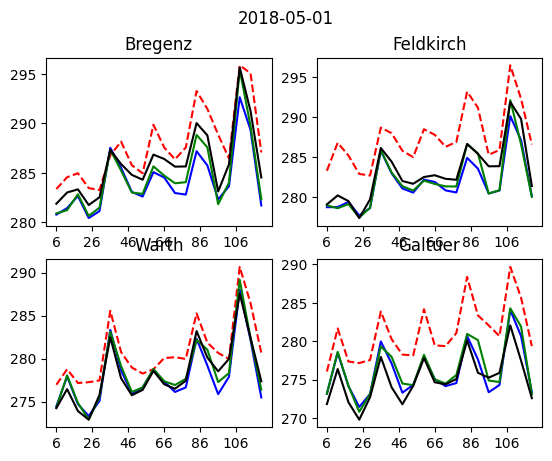

In [ ]:
import matplotlib.pyplot as plt

# plot the data for a given day
# we have forecasts/observations for the next 5 days with 6h time step (i.e. 20 steps)
# 4 subplots (4 stations)
fig, ax =plt.subplots(2,2)
# the Xticks are the lead times (6h, 12h, .... , 120h)
a=np.arange(6,121,step=6)
plt.setp(ax, xticks=np.arange(6,121,step=20))
# the stations
statnames = ['Bregenz','Feldkirch','Warth','Galtuer']
# the given day
day='2018-05-01'
i=0
for df in [datast1, datast2, datast3, datast4]:
    d_arr = df[df['day']==day]
    obs = d_arr['obs'] #observation
    h = d_arr['hres']  # high resolution
    d1 = d_arr['0']  # control term
    d2 = np.mean(d_arr.iloc[:,4:],axis=1) # mean of the 51-ensemble

    ax[i//2,i%2].plot(a,obs,ls='--',c='r') #minute 15 gives an explanation of the color
    ax[i//2,i%2].plot(a,d2,c='b') #mean
    ax[i//2,i%2].plot(a,d1,c='g') #0
    ax[i//2,i%2].plot(a,h,c='k') #high resolution
    ax[i//2,i%2].set_title(statnames[i])
    i = i+1
fig.suptitle(day)
plt.show()

#### adding mean column for forecasts

In [ ]:
# # this looks redundant since when splitting.. the mean is automatically included..
# # get mean of '1' to '50'

# datast1 = add_mean_column(datast1)
# datast2 = add_mean_column(datast2)
# dataset3 = add_mean_column(datast3)
# datast4 = add_mean_column(datast4)

#### splitting all the data into test and train

In [ ]:
# Splitting the data

dataset1_train, datast1_test = my_train_test_split(datast1, '2018-01-01')
dataset2_train, datast2_test = my_train_test_split(datast2, '2018-01-01')
dataset3_train, datast3_test = my_train_test_split(datast3, '2018-01-01')
dataset4_train, datast4_test = my_train_test_split(datast4, '2018-01-01')

/tmp/ipython-input-2741514633.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainset['mean'] = trainset.loc[:, ensemble_cols].mean(axis=1)
/tmp/ipython-input-2741514633.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testset['mean'] = testset.loc[:, ensemble_cols].mean(axis=1)
/tmp/ipython-input-2741514633.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [ ]:
# # getting the error values

# from sklearn.metrics import mean_squared_error

# err1_h = mean_squared_error(datast1_test['obs'], datast1_test['hres'])
# err1_0 = mean_squared_error(datast1_test['obs'], datast1_test['0'])
# err1_mean = mean_squared_error(datast1_test['obs'], datast1_test['mean'])

# err2_h = mean_squared_error(datast2_test['obs'], datast2_test['hres'])
# err2_0 = mean_squared_error(datast2_test['obs'], datast2_test['0'])
# err2_mean = mean_squared_error(datast2_test['obs'], datast2_test['mean'])

# err3_h = mean_squared_error(datast3_test['obs'], datast3_test['hres'])
# err3_0 = mean_squared_error(datast3_test['obs'], datast3_test['0'])
# err3_mean = mean_squared_error(datast3_test['obs'], datast3_test['mean'])

# err4_h = mean_squared_error(datast4_test['obs'], datast4_test['hres'])
# err4_0 = mean_squared_error(datast4_test['obs'], datast4_test['0'])
# err4_mean = mean_squared_error(datast4_test['obs'], datast4_test['mean'])

In [ ]:
# # The error values are large.. can we train a neural net to reduce them?
# # we can start with high resolution column, then proceed to the others..

# print(err1_h)
# print(err1_0)
# print(err1_mean)
# print()
# print(err2_h)
# print(err2_0)
# print(err2_mean)
# print()
# print(err3_h)
# print(err3_0)
# print(err3_mean)
# print()
# print(err4_h)
# print(err4_0)
# print(err4_mean)

### baselines for error considering single features

In [ ]:
# not reusable so i can just define it here.. no need to copy it to HELPER FUNCTIONS

def mse_forecast_obs(datast):
  from sklearn.metrics import mean_squared_error

  err_h = mean_squared_error(datast['obs'], datast['hres'])
  err_0 = mean_squared_error(datast['obs'], datast['0'])
  err_mean = mean_squared_error(datast['obs'], datast['mean'])

  print (f"Hres Vs Observation:{err_h}")
  print (f"Control Vs Observation:{err_0}")
  print (f"Mean Vs Observation:{err_mean}")

In [ ]:
mse_forecast_obs(datast1_test)

Hres Vs Observation:6.9484848229659395
Control Vs Observation:12.329825560256005
Mean Vs Observation:11.865555112388904


In [ ]:
mse_forecast_obs(datast2_test)

Hres Vs Observation:19.857896937966682
Control Vs Observation:28.925971209743906
Mean Vs Observation:27.792997627764663


In [ ]:
mse_forecast_obs(datast3_test)

Hres Vs Observation:14.537007443977865
Control Vs Observation:18.221447295567923
Mean Vs Observation:17.477645917110095


In [ ]:
mse_forecast_obs(datast4_test)

Hres Vs Observation:31.489444086345465
Control Vs Observation:28.12253688533403
Mean Vs Observation:27.00070567424268


### QUESTIONS, EXPERIMENTS AND NOTES (TASK 1)

**Question**: Can we get weather forecasts that are better than the weather forecasts in the dataset(The best forecasts was from the hres, can we beat that baseline)? **Experiment!**

From this part, we will consider the first dataset only (for Bregenze) for all experiments.

Specifically, `datast1_train` is used in **Experiment 1 and 2** during training. The test set `datast1_test` is also used (will.. coz as i am writing it has not yet been used). We use this datast1 because it has all the features used in the two experiments.

In **Experiment 3 and beyond**, we add more features, then split the data again, so that dataset will be used, as well as its respective test set.

---
---

**Experiment 1:** Just use high resolution as the feature (temperature was in K)

- I don't know why my neural networks are stuck at an mse of approx 4510. I have tried different things but nothing is helping. Initial model architecture was weirdly large for 1 feature

- The second run was just 1 linear layer with 1 neuron (a typical SLR model that I could have done using sklearn or by raw code). There was no need of using that many epochs.

- run 1-3 show that a smaller learning rate is better as it leads to faster convergence. This is sort of counter-intuitive, unless a larger lr causes oscillations, and thus late convergence.

- run 4 shows that Adam was the cause of my earlier problems.. the loss is too big.. **WHY?** Run 6 also shows that Adam is still bad

- Run 5b used ReLU as an activation funcion. nan values implied that gradients exploded.

- The conclusion of this experiment is that if we have 1 input feature, and the relationship between the target and the feature is linear, then learning more features is actually redundant and it would be best to just use a simple linear regression model. It led to the best MSE of about 5.41 in the validation loss. Test loss is similar
---



**Experiment 2:** Use high res, lt and mean of the ensemble (temperature was in K). Maybe I should try using the ensemble here as well.

I also want to add the day as a feature.

- Nothing is improving.. I am still getting stuck at 4510, despite changing things

- In run 0, I tried using a Multiple linear regression model (without activation functions) and using just 1 layer. This was the best model in Experiment 2 with a validation loss of around 5.

- The closest to the MLR was in run 3, with a validation loss around 9
---

**Experiment 3:** Using two input heads

- Looks like the training error has reduced to arond 3 (lowest) and validation loss to around 5. I am not sure if it is because of the transformation from celsius to kelvin or the model is actually improving. The validation is still similar though. This is the closest however we have gotten to the SLR we had in the start.
---
---
**More to do:**
- We have only used the validation errors to estimate the performances of our models. We need to define a function for predicting using the test set and record the performance for the models that seemed to perform well on the validation set. The target for the **Point forecasts** is to beat the **hres forecasts** which seemed to be the best forecasts, failure to do so, would mean that the project is quite obsolete (as far as the point forecasts is concerned)

### Experiment 1

### a look at the dataset

#### notes: average temp is 280 K, equiv to 7 deg Cel.. so it is always positive

In [ ]:
datast1.head()

,day,lt,obs,hres,0,1,2,3,4,5,...,41,42,43,44,45,46,47,48,49,50
0,2017-01-01,1,268.25,271.993652,268.316650,268.002686,268.082764,268.019043,268.043701,268.136475,...,268.048981,267.825195,267.859192,267.699219,267.835297,267.899170,268.290527,267.426758,267.745605,267.807068
1,2017-01-01,2,270.65,274.583252,276.755615,276.386475,277.529297,277.208984,276.623779,276.834717,...,277.453369,276.549072,277.210205,276.338379,276.715088,276.836914,277.045654,276.505371,276.788574,276.864746
2,2017-01-01,3,270.05,274.211182,269.624023,269.583984,270.094727,269.682129,269.518555,269.781738,...,270.127930,270.262207,269.717041,270.621094,270.277588,269.752930,269.773438,269.601074,269.741455,269.543701
3,2017-01-01,4,268.15,271.106689,267.018188,266.812897,266.745209,267.104187,265.780823,266.594971,...,266.721680,267.171082,267.151245,267.081909,267.383728,266.410583,266.945435,266.674225,267.238068,266.479126
4,2017-01-01,5,268.15,271.679932,266.210999,265.982910,266.553650,266.457153,266.416931,266.215942,...,265.956329,266.500854,266.976929,266.265137,266.599365,266.675201,267.201965,266.455566,266.114929,265.920288


In [ ]:
datast1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   obs     14600 non-null  float64       
 3   hres    14600 non-null  float64       
 4   0       14600 non-null  float64       
 5   1       14600 non-null  float64       
 6   2       14600 non-null  float64       
 7   3       14600 non-null  float64       
 8   4       14600 non-null  float64       
 9   5       14600 non-null  float64       
 10  6       14600 non-null  float64       
 11  7       14600 non-null  float64       
 12  8       14600 non-null  float64       
 13  9       14600 non-null  float64       
 14  10      14600 non-null  float64       
 15  11      14600 non-null  float64       
 16  12      14600 non-null  float64       
 17  13      14600 non-null  float64       
 18  14    

### scatter plot of hres vs obs

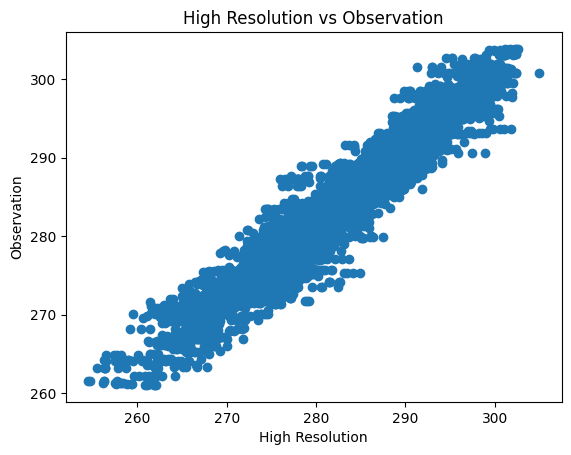

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(dataset1_train['hres'], dataset1_train['obs'])
plt.xlabel('High Resolution')
plt.ylabel('Observation')
plt.title('High Resolution vs Observation')
plt.show();

#### feature selection, split (train and validation), normalization

In [ ]:
X_train_norm, y_train, X_val_norm, y_val, mean, std = feature_selection_norm(dataset1_train, ['hres'])

Splitting complete
         Training set size: 5840
         Validation set size: 1460

Feature extraction is complete

Rows before Normalization:
                     hres
5931  282.293457
3739  291.251953

Normalization is complete

Rows after Normalization:
         [[0.00612563]
 [1.03347418]]


#### to DataLoader

In [ ]:
train_dl, val_dl = to_data_loader(X_train_norm, y_train, X_val_norm, y_val, batch_size = 64)

Conversion to Tensor dataset is complete
   Type: <class 'torch.utils.data.dataset.TensorDataset'>

Conversion to DataLoader is complete
   Feature shape per batch: torch.Size([64, 1])
   Target shape per batch: torch.Size([64]) 
   Total number of batches: 92
   Size of training set: 5840
   Size of validation set: 1460


#### run 1

SLR with SGD with lr=0.01

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1)

  def forward(self, x):
    return self.layer(x)

model = Net()
print(model)

Net(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.01)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 1019.85, Validation Loss: 5.54
Epoch: 2, Training Loss: 5.05, Validation Loss: 5.65
Epoch: 3, Training Loss: 5.13, Validation Loss: 5.60
Epoch: 4, Training Loss: 5.12, Validation Loss: 6.27
Epoch: 5, Training Loss: 5.03, Validation Loss: 5.73
Epoch: 6, Training Loss: 5.06, Validation Loss: 5.60
Epoch: 7, Training Loss: 5.04, Validation Loss: 5.62
Epoch: 8, Training Loss: 5.13, Validation Loss: 5.80
Epoch: 9, Training Loss: 5.21, Validation Loss: 5.57
Epoch: 10, Training Loss: 5.11, Validation Loss: 6.08
Epoch: 11, Training Loss: 5.11, Validation Loss: 5.50
Epoch: 12, Training Loss: 5.18, Validation Loss: 6.05
Epoch: 13, Training Loss: 5.12, Validation Loss: 5.60
Epoch: 14, Training Loss: 5.31, Validation Loss: 6.17
Epoch: 15, Training Loss: 5.16, Validation Loss: 5.48
Epoch: 16, Training Loss: 5.11, Validation Loss: 5.52
Epoch: 17, Training Loss: 5.12, Validation Loss: 5.72
Epoch: 18, Training Loss: 5.03, Validation Loss: 5.52
Epoch: 19, Training Loss: 5.15, Va

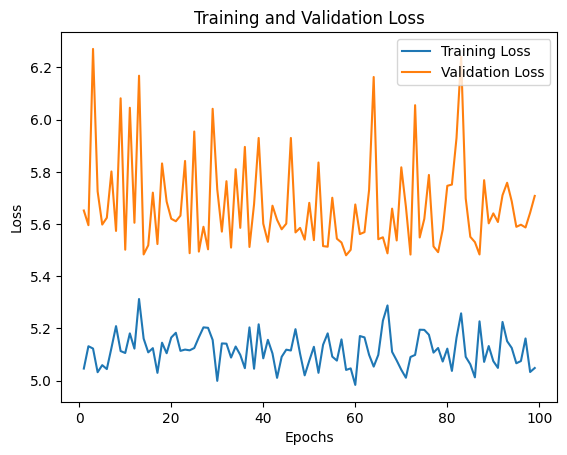

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 2

lr reduced to 0.003

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1)

  def forward(self, x):
    return self.layer(x)

model = Net()
print(model)

Net(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.003)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 1420.92, Validation Loss: 5.53
Epoch: 2, Training Loss: 4.85, Validation Loss: 5.48
Epoch: 3, Training Loss: 4.84, Validation Loss: 5.58
Epoch: 4, Training Loss: 4.84, Validation Loss: 5.55
Epoch: 5, Training Loss: 4.86, Validation Loss: 5.52
Epoch: 6, Training Loss: 4.86, Validation Loss: 5.53
Epoch: 7, Training Loss: 4.84, Validation Loss: 5.50
Epoch: 8, Training Loss: 4.86, Validation Loss: 5.50
Epoch: 9, Training Loss: 4.86, Validation Loss: 5.49
Epoch: 10, Training Loss: 4.85, Validation Loss: 5.48
Epoch: 11, Training Loss: 4.87, Validation Loss: 5.48
Epoch: 12, Training Loss: 4.85, Validation Loss: 5.52
Epoch: 13, Training Loss: 4.86, Validation Loss: 5.53
Epoch: 14, Training Loss: 4.85, Validation Loss: 5.48
Epoch: 15, Training Loss: 4.85, Validation Loss: 5.58
Epoch: 16, Training Loss: 4.85, Validation Loss: 5.49
Epoch: 17, Training Loss: 4.86, Validation Loss: 5.56
Epoch: 18, Training Loss: 4.85, Validation Loss: 5.55
Epoch: 19, Training Loss: 4.84, Va

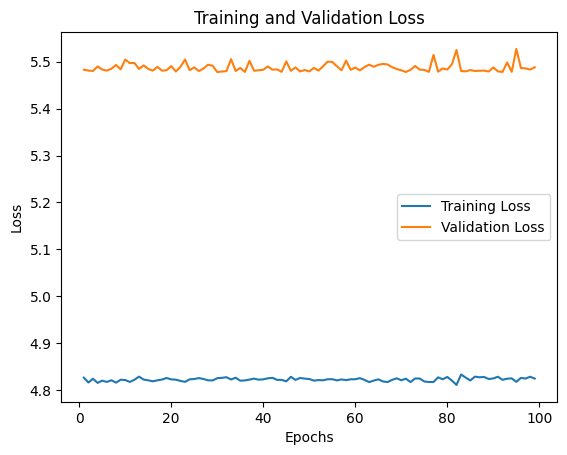

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 3

lr = 0.001

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1)

  def forward(self, x):
    return self.layer(x)

model = Net()
print(model)

Net(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 3675.30, Validation Loss: 5.48
Epoch: 2, Training Loss: 4.83, Validation Loss: 5.48
Epoch: 3, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 4, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 5, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 6, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 7, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 8, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 9, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 10, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 11, Training Loss: 4.82, Validation Loss: 5.50
Epoch: 12, Training Loss: 4.82, Validation Loss: 5.50
Epoch: 13, Training Loss: 4.82, Validation Loss: 5.50
Epoch: 14, Training Loss: 4.83, Validation Loss: 5.48
Epoch: 15, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 16, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 17, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 18, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 19, Training Loss: 4.82, Va

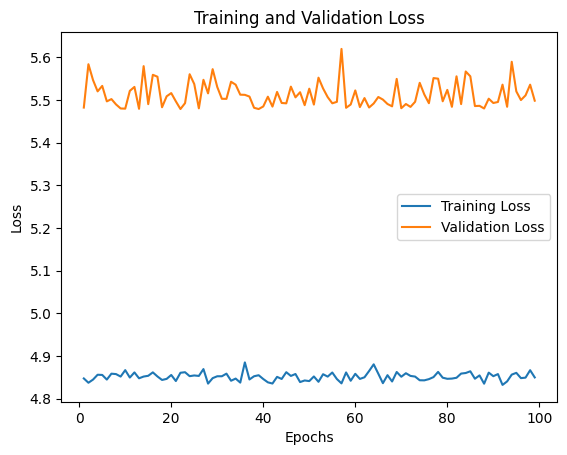

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 3 (was best, so i save)

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1)

  def forward(self, x):
    return self.layer(x)

model = Net()
print(model)

Net(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train_save(model, train_dl, val_dl, optimizer, loss_fn, model_name = 'ex1_run3', epochs = 100, device = device)

Epoch: 1, Training Loss: 4.83, Validation Loss: 5.49
Epoch: 2, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 3, Training Loss: 4.83, Validation Loss: 5.48
Epoch: 4, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 5, Training Loss: 4.82, Validation Loss: 5.50
Epoch: 6, Training Loss: 4.83, Validation Loss: 5.49
Epoch: 7, Training Loss: 4.83, Validation Loss: 5.48
Epoch: 8, Training Loss: 4.82, Validation Loss: 5.48
Epoch: 9, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 10, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 11, Training Loss: 4.83, Validation Loss: 5.50
Epoch: 12, Training Loss: 4.83, Validation Loss: 5.48
Epoch: 13, Training Loss: 4.82, Validation Loss: 5.50
Epoch: 14, Training Loss: 4.83, Validation Loss: 5.49
Epoch: 15, Training Loss: 4.82, Validation Loss: 5.49
Epoch: 16, Training Loss: 4.83, Validation Loss: 5.48
Epoch: 17, Training Loss: 4.83, Validation Loss: 5.49
Epoch: 18, Training Loss: 4.82, Validation Loss: 5.50
Epoch: 19, Training Loss: 4.82, Valid

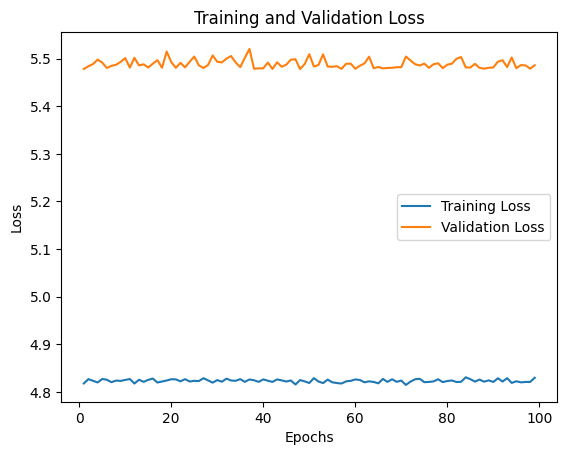

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 4

using Adam

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1)

  def forward(self, x):
    return self.layer(x)

model = Net()
print(model)

Net(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 81001.79, Validation Loss: 80953.41
Epoch: 2, Training Loss: 80949.37, Validation Loss: 80901.04
Epoch: 3, Training Loss: 80896.89, Validation Loss: 80848.61
Epoch: 4, Training Loss: 80844.45, Validation Loss: 80796.23
Epoch: 5, Training Loss: 80792.03, Validation Loss: 80743.87
Epoch: 6, Training Loss: 80739.62, Validation Loss: 80691.49
Epoch: 7, Training Loss: 80687.23, Validation Loss: 80639.17
Epoch: 8, Training Loss: 80634.87, Validation Loss: 80586.89
Epoch: 9, Training Loss: 80582.53, Validation Loss: 80534.65
Epoch: 10, Training Loss: 80530.21, Validation Loss: 80482.39
Epoch: 11, Training Loss: 80477.93, Validation Loss: 80430.12
Epoch: 12, Training Loss: 80425.64, Validation Loss: 80377.90
Epoch: 13, Training Loss: 80373.40, Validation Loss: 80325.80
Epoch: 14, Training Loss: 80321.17, Validation Loss: 80273.64
Epoch: 15, Training Loss: 80268.97, Validation Loss: 80221.52
Epoch: 16, Training Loss: 80216.80, Validation Loss: 80169.42
Epoch: 17, Traini

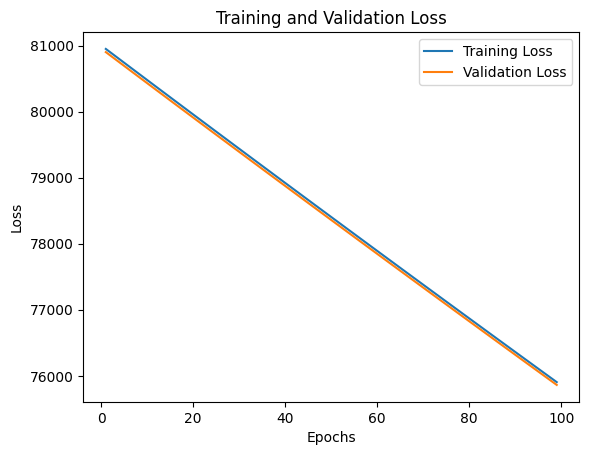

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### to do

- This was SLR. Check if the results would have been the same if we used scikit-learn

#### run 5
- i want to see if increasing the number of features will improve the model. Since this means that we are moving from a linear model to a non-linear model (because of Tanh), I hope it will be better. By the way Tanh is used because we want to maintain the negative values, since temperature forecasts can have this.

- lr is left at 0.001 coz i figured its the best one.

- optimizer is SGD

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
     nn.Linear(1, 2),
     nn.Tanh(),
     nn.Linear(2, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 2338.12, Validation Loss: 57.09
Epoch: 2, Training Loss: 56.09, Validation Loss: 53.31
Epoch: 3, Training Loss: 54.29, Validation Loss: 52.29
Epoch: 4, Training Loss: 53.37, Validation Loss: 51.13
Epoch: 5, Training Loss: 52.40, Validation Loss: 50.98
Epoch: 6, Training Loss: 51.24, Validation Loss: 49.71
Epoch: 7, Training Loss: 49.78, Validation Loss: 48.26
Epoch: 8, Training Loss: 48.33, Validation Loss: 46.82
Epoch: 9, Training Loss: 47.01, Validation Loss: 45.79
Epoch: 10, Training Loss: 45.01, Validation Loss: 44.41
Epoch: 11, Training Loss: 43.80, Validation Loss: 43.02
Epoch: 12, Training Loss: 42.63, Validation Loss: 42.06
Epoch: 13, Training Loss: 41.54, Validation Loss: 40.73
Epoch: 14, Training Loss: 39.85, Validation Loss: 39.44
Epoch: 15, Training Loss: 38.77, Validation Loss: 38.39
Epoch: 16, Training Loss: 38.01, Validation Loss: 37.30
Epoch: 17, Training Loss: 37.24, Validation Loss: 36.77
Epoch: 18, Training Loss: 36.50, Validation Loss: 36.12

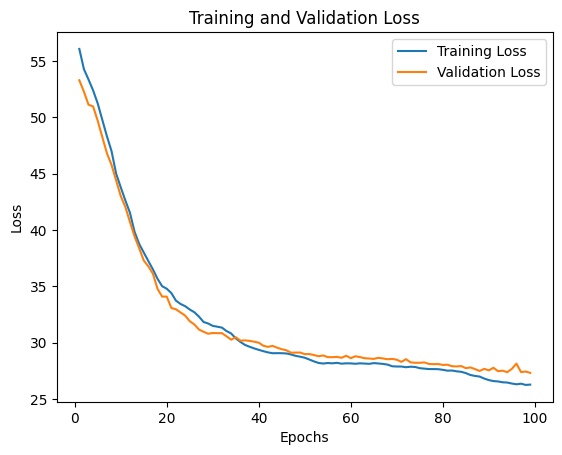

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 5b

- after seeing that the temp is in K, it is always positive and the tanh activation function may not be the best.. let us try ReLU.
- ReLU led to nan values for the error.. the suggestion was that it may have been an exploding gradients issue that could have been dealt with by gradient clipping. i ignored it, opted for sigmoid instead

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
     nn.Linear(1, 2),
     nn.Sigmoid(),
     nn.Linear(2, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 1972.31, Validation Loss: 72.03
Epoch: 2, Training Loss: 70.87, Validation Loss: 70.10
Epoch: 3, Training Loss: 71.39, Validation Loss: 70.92
Epoch: 4, Training Loss: 71.56, Validation Loss: 69.91
Epoch: 5, Training Loss: 70.69, Validation Loss: 70.08
Epoch: 6, Training Loss: 70.99, Validation Loss: 69.03
Epoch: 7, Training Loss: 70.53, Validation Loss: 70.05
Epoch: 8, Training Loss: 70.61, Validation Loss: 70.25
Epoch: 9, Training Loss: 70.88, Validation Loss: 71.21
Epoch: 10, Training Loss: 70.53, Validation Loss: 70.01
Epoch: 11, Training Loss: 70.63, Validation Loss: 69.25
Epoch: 12, Training Loss: 70.29, Validation Loss: 69.94
Epoch: 13, Training Loss: 69.50, Validation Loss: 68.10
Epoch: 14, Training Loss: 68.52, Validation Loss: 65.57
Epoch: 15, Training Loss: 67.19, Validation Loss: 69.89
Epoch: 16, Training Loss: 67.95, Validation Loss: 70.19
Epoch: 17, Training Loss: 68.24, Validation Loss: 70.66
Epoch: 18, Training Loss: 71.54, Validation Loss: 69.97

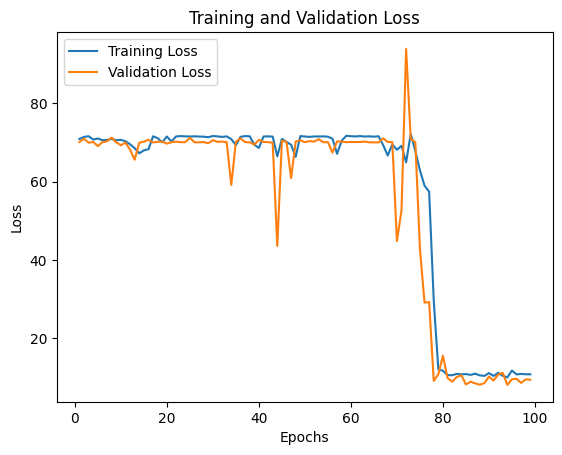

In [ ]:
plot_results(history_train[1:], history_val[1:])

In [ ]:
history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 10.99, Validation Loss: 10.33
Epoch: 2, Training Loss: 11.11, Validation Loss: 8.25
Epoch: 3, Training Loss: 10.93, Validation Loss: 8.15
Epoch: 4, Training Loss: 10.17, Validation Loss: 9.74
Epoch: 5, Training Loss: 11.11, Validation Loss: 8.12
Epoch: 6, Training Loss: 11.19, Validation Loss: 8.15
Epoch: 7, Training Loss: 10.74, Validation Loss: 8.73
Epoch: 8, Training Loss: 10.45, Validation Loss: 9.23
Epoch: 9, Training Loss: 10.80, Validation Loss: 8.11
Epoch: 10, Training Loss: 11.15, Validation Loss: 11.17
Epoch: 11, Training Loss: 10.16, Validation Loss: 10.42
Epoch: 12, Training Loss: 10.51, Validation Loss: 14.22
Epoch: 13, Training Loss: 10.96, Validation Loss: 9.20
Epoch: 14, Training Loss: 10.43, Validation Loss: 8.21
Epoch: 15, Training Loss: 10.79, Validation Loss: 8.67
Epoch: 16, Training Loss: 10.77, Validation Loss: 9.72
Epoch: 17, Training Loss: 10.92, Validation Loss: 10.33
Epoch: 18, Training Loss: 11.44, Validation Loss: 10.03
Epoch: 19, Tr

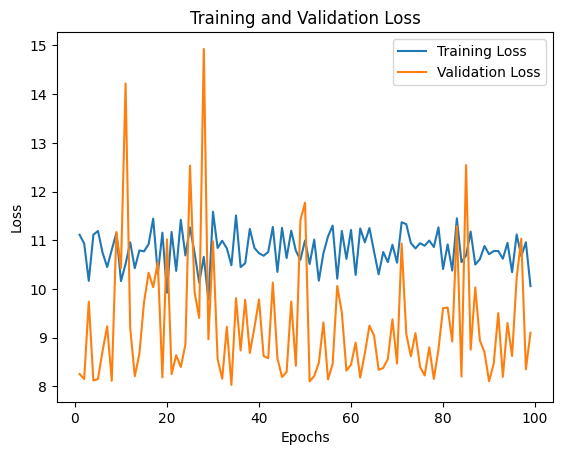

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 6

what if i used Adam with 2 features

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
     nn.Linear(1, 2),
     nn.Tanh(),
     nn.Linear(2, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 80413.29, Validation Loss: 80327.82
Epoch: 2, Training Loss: 80291.35, Validation Loss: 80216.28
Epoch: 3, Training Loss: 80188.52, Validation Loss: 80120.96
Epoch: 4, Training Loss: 80098.42, Validation Loss: 80034.43
Epoch: 5, Training Loss: 80012.68, Validation Loss: 79946.97
Epoch: 6, Training Loss: 79919.72, Validation Loss: 79844.76
Epoch: 7, Training Loss: 79802.41, Validation Loss: 79707.44
Epoch: 8, Training Loss: 79640.87, Validation Loss: 79519.00
Epoch: 9, Training Loss: 79430.13, Validation Loss: 79289.23
Epoch: 10, Training Loss: 79191.09, Validation Loss: 79044.82
Epoch: 11, Training Loss: 78946.24, Validation Loss: 78801.39
Epoch: 12, Training Loss: 78705.50, Validation Loss: 78564.15
Epoch: 13, Training Loss: 78471.94, Validation Loss: 78334.73
Epoch: 14, Training Loss: 78246.35, Validation Loss: 78113.26
Epoch: 15, Training Loss: 78028.54, Validation Loss: 77899.30
Epoch: 16, Training Loss: 77817.88, Validation Loss: 77692.11
Epoch: 17, Traini

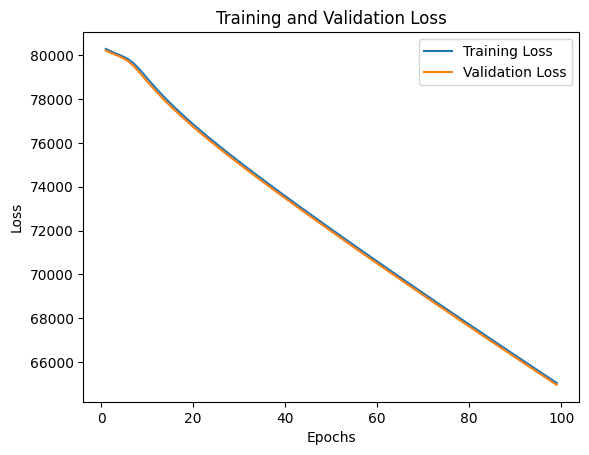

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 7

let us increase the features to 5 to confirm that adding features is not helpful.

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
     nn.Linear(1, 5),
     nn.Tanh(),
     nn.Linear(5, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=5, bias=True)
    (1): Tanh()
    (2): Linear(in_features=5, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 1763.07, Validation Loss: 36.23
Epoch: 2, Training Loss: 37.08, Validation Loss: 34.28
Epoch: 3, Training Loss: 34.62, Validation Loss: 32.63
Epoch: 4, Training Loss: 33.22, Validation Loss: 31.89
Epoch: 5, Training Loss: 31.87, Validation Loss: 30.83
Epoch: 6, Training Loss: 31.01, Validation Loss: 30.39
Epoch: 7, Training Loss: 30.20, Validation Loss: 33.03
Epoch: 8, Training Loss: 29.56, Validation Loss: 28.98
Epoch: 9, Training Loss: 29.00, Validation Loss: 28.99
Epoch: 10, Training Loss: 28.81, Validation Loss: 28.79
Epoch: 11, Training Loss: 28.43, Validation Loss: 28.97
Epoch: 12, Training Loss: 28.20, Validation Loss: 28.14
Epoch: 13, Training Loss: 27.82, Validation Loss: 28.26
Epoch: 14, Training Loss: 27.50, Validation Loss: 27.65
Epoch: 15, Training Loss: 27.19, Validation Loss: 27.46
Epoch: 16, Training Loss: 26.98, Validation Loss: 27.40
Epoch: 17, Training Loss: 27.06, Validation Loss: 27.10
Epoch: 18, Training Loss: 27.05, Validation Loss: 27.19

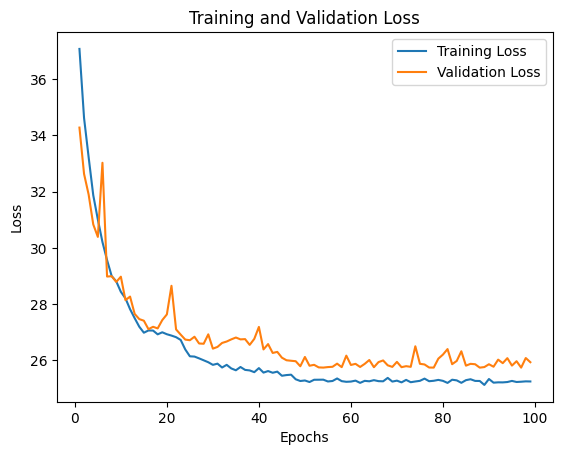

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 7b

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
     nn.Linear(1, 5),
     nn.Sigmoid(),
     nn.Linear(5, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=5, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=5, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 200, device = device)

Epoch: 1, Training Loss: 1425.20, Validation Loss: 74.53
Epoch: 2, Training Loss: 71.66, Validation Loss: 69.94
Epoch: 3, Training Loss: 71.68, Validation Loss: 70.68
Epoch: 4, Training Loss: 71.80, Validation Loss: 70.46
Epoch: 5, Training Loss: 71.65, Validation Loss: 69.95
Epoch: 6, Training Loss: 71.10, Validation Loss: 70.29
Epoch: 7, Training Loss: 71.03, Validation Loss: 70.14
Epoch: 8, Training Loss: 71.15, Validation Loss: 69.63
Epoch: 9, Training Loss: 71.35, Validation Loss: 70.71
Epoch: 10, Training Loss: 71.15, Validation Loss: 71.04
Epoch: 11, Training Loss: 71.22, Validation Loss: 71.57
Epoch: 12, Training Loss: 71.19, Validation Loss: 70.00
Epoch: 13, Training Loss: 70.97, Validation Loss: 70.00
Epoch: 14, Training Loss: 71.22, Validation Loss: 69.60
Epoch: 15, Training Loss: 71.05, Validation Loss: 71.01
Epoch: 16, Training Loss: 71.12, Validation Loss: 69.91
Epoch: 17, Training Loss: 71.06, Validation Loss: 69.67
Epoch: 18, Training Loss: 71.21, Validation Loss: 69.87

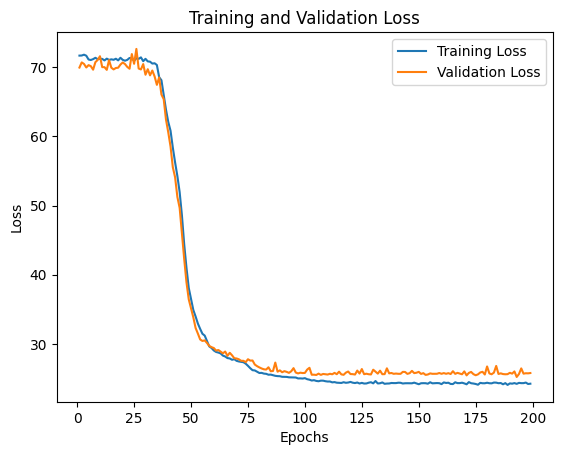

In [ ]:
plot_results(history_train[1:], history_val[1:])

In [ ]:
history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 200, device = device)

Epoch: 1, Training Loss: 24.28, Validation Loss: 25.69
Epoch: 2, Training Loss: 24.24, Validation Loss: 25.66
Epoch: 3, Training Loss: 24.15, Validation Loss: 26.74
Epoch: 4, Training Loss: 24.08, Validation Loss: 25.62
Epoch: 5, Training Loss: 24.27, Validation Loss: 25.70
Epoch: 6, Training Loss: 24.28, Validation Loss: 25.41
Epoch: 7, Training Loss: 24.38, Validation Loss: 25.72
Epoch: 8, Training Loss: 24.37, Validation Loss: 25.76
Epoch: 9, Training Loss: 24.39, Validation Loss: 25.88
Epoch: 10, Training Loss: 24.33, Validation Loss: 25.90
Epoch: 11, Training Loss: 24.35, Validation Loss: 25.64
Epoch: 12, Training Loss: 24.36, Validation Loss: 25.95
Epoch: 13, Training Loss: 24.35, Validation Loss: 25.96
Epoch: 14, Training Loss: 24.29, Validation Loss: 27.97
Epoch: 15, Training Loss: 24.27, Validation Loss: 25.62
Epoch: 16, Training Loss: 24.32, Validation Loss: 25.71
Epoch: 17, Training Loss: 24.28, Validation Loss: 25.61
Epoch: 18, Training Loss: 24.23, Validation Loss: 25.98
E

#### Test set evaluation of the best model in Experiment 1

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1)

  def forward(self, x):
    return self.layer(x)

In [ ]:
model = torch.load(os.path.join(PATH_MODELS, 'ex1_run3'), weights_only = False)

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

pred, loss = make_point_forecast(model, datast1_test, ['hres'], mean_ = mean, std_ = std, device = device)

In [ ]:
loss

tensor(5.2263)

### Experiment 2


In [ ]:
X_train_norm, y_train, X_val_norm, y_val, mean, std = feature_selection_norm(dataset1_train, ['hres', 'lt', '0', 'mean'])

Splitting complete
         Training set size: 5840
         Validation set size: 1460

Feature extraction is complete

Rows before Normalization:
                     hres  lt           0        mean
5931  282.293457  12  280.082275  280.156913
3739  291.251953  20  289.411621  289.205686

Normalization is complete

Rows after Normalization:
         [[ 0.00612563  0.26139396 -0.09465618 -0.08277139]
 [ 1.03347418  1.64868531  0.93823812  0.9319345 ]]


In [ ]:
train_dl, val_dl = to_data_loader(X_train_norm, y_train, X_val_norm, y_val, batch_size = 64)

Conversion to Tensor dataset is complete
   Type: <class 'torch.utils.data.dataset.TensorDataset'>

Conversion to DataLoader is complete
   Feature shape per batch: torch.Size([64, 4])
   Target shape per batch: torch.Size([64]) 
   Total number of batches: 92
   Size of training set: 5840
   Size of validation set: 1460


#### run 0

i just remembered that I did not do a MLR where i don't include an activation function for non-linearity

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(4, 1),
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 3702.81, Validation Loss: 5.71
Epoch: 2, Training Loss: 4.92, Validation Loss: 5.61
Epoch: 3, Training Loss: 4.83, Validation Loss: 5.52
Epoch: 4, Training Loss: 4.79, Validation Loss: 5.46
Epoch: 5, Training Loss: 4.72, Validation Loss: 5.47
Epoch: 6, Training Loss: 4.70, Validation Loss: 5.39
Epoch: 7, Training Loss: 4.68, Validation Loss: 5.38
Epoch: 8, Training Loss: 4.65, Validation Loss: 5.38
Epoch: 9, Training Loss: 4.64, Validation Loss: 5.34
Epoch: 10, Training Loss: 4.64, Validation Loss: 5.34
Epoch: 11, Training Loss: 4.61, Validation Loss: 5.32
Epoch: 12, Training Loss: 4.60, Validation Loss: 5.30
Epoch: 13, Training Loss: 4.60, Validation Loss: 5.30
Epoch: 14, Training Loss: 4.59, Validation Loss: 5.30
Epoch: 15, Training Loss: 4.60, Validation Loss: 5.29
Epoch: 16, Training Loss: 4.60, Validation Loss: 5.30
Epoch: 17, Training Loss: 4.58, Validation Loss: 5.29
Epoch: 18, Training Loss: 4.58, Validation Loss: 5.29
Epoch: 19, Training Loss: 4.58, Va

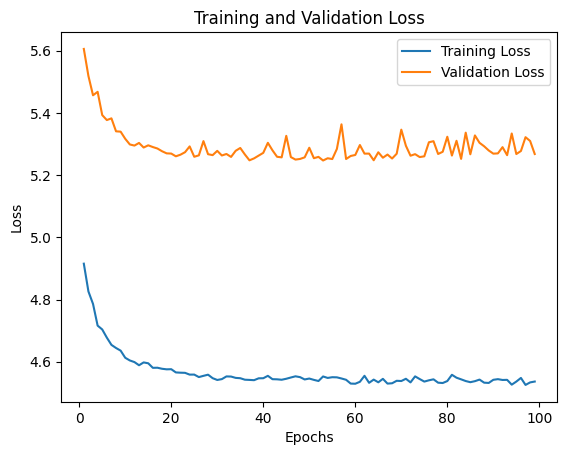

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 1

downscale the layers and see how it is

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(4, 2),
     nn.Tanh(),
     nn.Linear(2, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 3451.03, Validation Loss: 37.59
Epoch: 2, Training Loss: 37.40, Validation Loss: 35.94
Epoch: 3, Training Loss: 34.27, Validation Loss: 35.55
Epoch: 4, Training Loss: 33.43, Validation Loss: 34.32
Epoch: 5, Training Loss: 32.62, Validation Loss: 33.66
Epoch: 6, Training Loss: 32.35, Validation Loss: 33.02
Epoch: 7, Training Loss: 31.94, Validation Loss: 32.24
Epoch: 8, Training Loss: 31.33, Validation Loss: 31.80
Epoch: 9, Training Loss: 30.72, Validation Loss: 31.57
Epoch: 10, Training Loss: 30.35, Validation Loss: 31.06
Epoch: 11, Training Loss: 29.94, Validation Loss: 30.80
Epoch: 12, Training Loss: 29.49, Validation Loss: 30.46
Epoch: 13, Training Loss: 29.37, Validation Loss: 30.10
Epoch: 14, Training Loss: 29.14, Validation Loss: 29.77
Epoch: 15, Training Loss: 29.04, Validation Loss: 29.90
Epoch: 16, Training Loss: 29.03, Validation Loss: 29.71
Epoch: 17, Training Loss: 28.99, Validation Loss: 29.52
Epoch: 18, Training Loss: 28.71, Validation Loss: 29.48

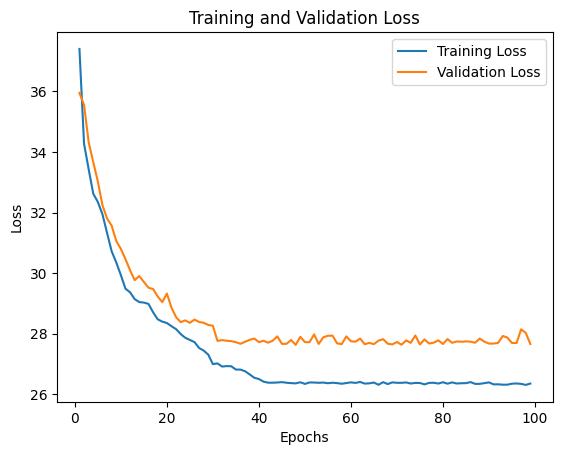

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 1 (more epochs)

In [ ]:
history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 26.35, Validation Loss: 27.77
Epoch: 2, Training Loss: 26.41, Validation Loss: 27.66
Epoch: 3, Training Loss: 26.36, Validation Loss: 27.67
Epoch: 4, Training Loss: 26.39, Validation Loss: 27.75
Epoch: 5, Training Loss: 26.33, Validation Loss: 27.81
Epoch: 6, Training Loss: 26.35, Validation Loss: 27.64
Epoch: 7, Training Loss: 26.35, Validation Loss: 27.66
Epoch: 8, Training Loss: 26.36, Validation Loss: 27.72
Epoch: 9, Training Loss: 26.35, Validation Loss: 27.67
Epoch: 10, Training Loss: 26.33, Validation Loss: 27.72
Epoch: 11, Training Loss: 26.28, Validation Loss: 28.71
Epoch: 12, Training Loss: 26.37, Validation Loss: 27.73
Epoch: 13, Training Loss: 26.36, Validation Loss: 27.66
Epoch: 14, Training Loss: 26.41, Validation Loss: 27.91
Epoch: 15, Training Loss: 26.35, Validation Loss: 27.67
Epoch: 16, Training Loss: 26.33, Validation Loss: 27.65
Epoch: 17, Training Loss: 26.33, Validation Loss: 27.79
Epoch: 18, Training Loss: 26.32, Validation Loss: 27.69
E

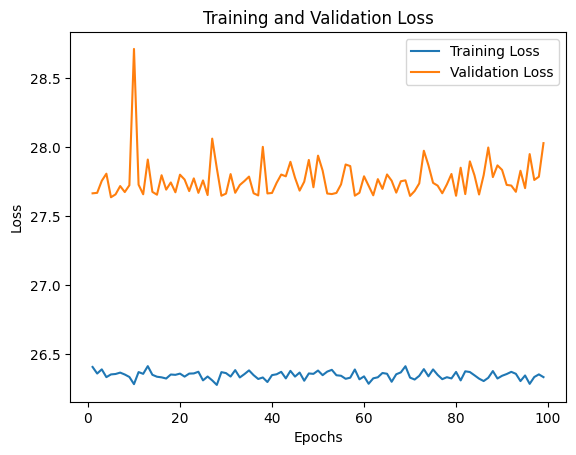

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 1b

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(4, 2),
     nn.Sigmoid(),
     nn.Linear(2, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=2, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 1964.67, Validation Loss: 70.20
Epoch: 2, Training Loss: 71.59, Validation Loss: 70.80
Epoch: 3, Training Loss: 71.53, Validation Loss: 70.70
Epoch: 4, Training Loss: 71.49, Validation Loss: 70.11
Epoch: 5, Training Loss: 71.47, Validation Loss: 70.33
Epoch: 6, Training Loss: 71.52, Validation Loss: 70.15
Epoch: 7, Training Loss: 71.42, Validation Loss: 70.02
Epoch: 8, Training Loss: 71.50, Validation Loss: 70.02
Epoch: 9, Training Loss: 71.51, Validation Loss: 70.35
Epoch: 10, Training Loss: 71.50, Validation Loss: 70.32
Epoch: 11, Training Loss: 71.67, Validation Loss: 70.21
Epoch: 12, Training Loss: 71.42, Validation Loss: 70.87
Epoch: 13, Training Loss: 71.44, Validation Loss: 70.17
Epoch: 14, Training Loss: 71.48, Validation Loss: 70.08
Epoch: 15, Training Loss: 71.55, Validation Loss: 70.48
Epoch: 16, Training Loss: 71.63, Validation Loss: 70.02
Epoch: 17, Training Loss: 71.53, Validation Loss: 70.03
Epoch: 18, Training Loss: 71.50, Validation Loss: 70.57

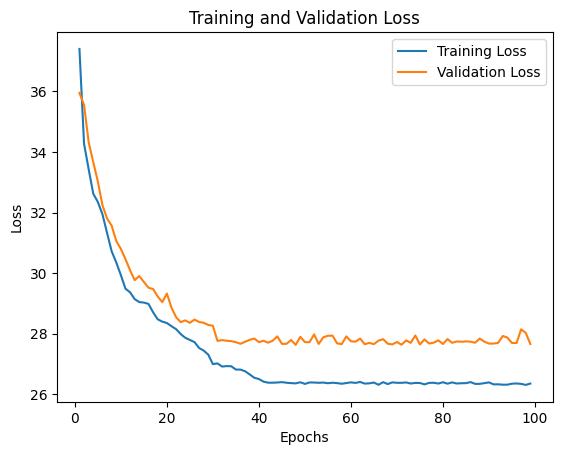

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 2

increase the number of features and layers

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(4, 16),
     nn.Tanh(),
     nn.Linear(16, 8),
     nn.Tanh(),
     nn.Linear(8, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 2426.40, Validation Loss: 39.84
Epoch: 2, Training Loss: 27.18, Validation Loss: 23.47
Epoch: 3, Training Loss: 22.26, Validation Loss: 22.26
Epoch: 4, Training Loss: 21.41, Validation Loss: 21.96
Epoch: 5, Training Loss: 21.21, Validation Loss: 21.78
Epoch: 6, Training Loss: 21.09, Validation Loss: 21.44
Epoch: 7, Training Loss: 20.70, Validation Loss: 21.20
Epoch: 8, Training Loss: 20.22, Validation Loss: 20.58
Epoch: 9, Training Loss: 19.96, Validation Loss: 19.94
Epoch: 10, Training Loss: 19.14, Validation Loss: 20.32
Epoch: 11, Training Loss: 20.09, Validation Loss: 21.60
Epoch: 12, Training Loss: 19.49, Validation Loss: 19.88
Epoch: 13, Training Loss: 18.87, Validation Loss: 19.52
Epoch: 14, Training Loss: 18.64, Validation Loss: 19.37
Epoch: 15, Training Loss: 18.64, Validation Loss: 36.08
Epoch: 16, Training Loss: 20.13, Validation Loss: 19.40
Epoch: 17, Training Loss: 18.01, Validation Loss: 19.09
Epoch: 18, Training Loss: 17.98, Validation Loss: 19.31

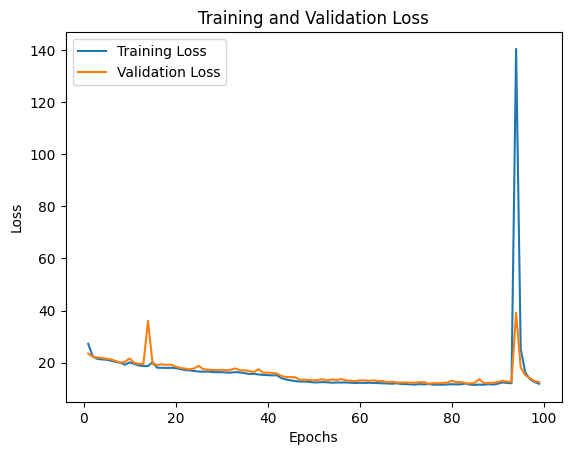

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 3

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(4, 32),
     nn.Tanh(),
     nn.Linear(32, 8),
     nn.Tanh(),
     nn.Linear(8, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 3908.09, Validation Loss: 67.26
Epoch: 2, Training Loss: 41.66, Validation Loss: 29.88
Epoch: 3, Training Loss: 27.64, Validation Loss: 24.71
Epoch: 4, Training Loss: 23.15, Validation Loss: 22.20
Epoch: 5, Training Loss: 23.18, Validation Loss: 21.93
Epoch: 6, Training Loss: 21.55, Validation Loss: 19.75
Epoch: 7, Training Loss: 20.11, Validation Loss: 18.49
Epoch: 8, Training Loss: 18.76, Validation Loss: 17.48
Epoch: 9, Training Loss: 17.71, Validation Loss: 17.39
Epoch: 10, Training Loss: 17.36, Validation Loss: 17.87
Epoch: 11, Training Loss: 17.16, Validation Loss: 16.68
Epoch: 12, Training Loss: 16.71, Validation Loss: 16.02
Epoch: 13, Training Loss: 16.11, Validation Loss: 15.70
Epoch: 14, Training Loss: 15.42, Validation Loss: 14.78
Epoch: 15, Training Loss: 14.15, Validation Loss: 13.58
Epoch: 16, Training Loss: 13.69, Validation Loss: 13.33
Epoch: 17, Training Loss: 13.50, Validation Loss: 13.27
Epoch: 18, Training Loss: 13.46, Validation Loss: 13.48

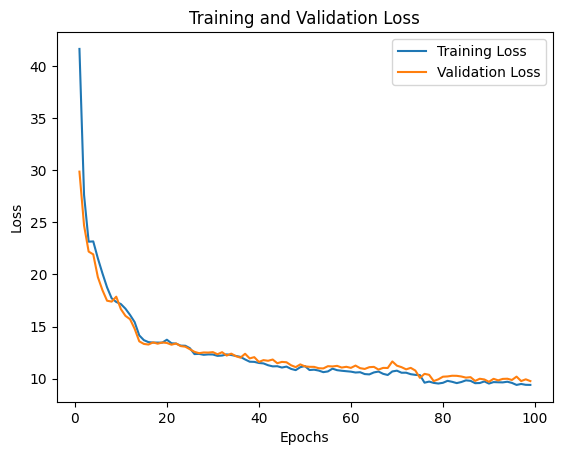

In [ ]:
plot_results(history_train[1:], history_val[1:])

In [ ]:
history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 9.45, Validation Loss: 9.68
Epoch: 2, Training Loss: 9.43, Validation Loss: 10.08
Epoch: 3, Training Loss: 9.44, Validation Loss: 10.31
Epoch: 4, Training Loss: 9.48, Validation Loss: 9.67
Epoch: 5, Training Loss: 9.38, Validation Loss: 10.01
Epoch: 6, Training Loss: 9.52, Validation Loss: 10.19
Epoch: 7, Training Loss: 9.65, Validation Loss: 9.91
Epoch: 8, Training Loss: 9.43, Validation Loss: 10.03
Epoch: 9, Training Loss: 9.39, Validation Loss: 10.03
Epoch: 10, Training Loss: 9.47, Validation Loss: 9.83
Epoch: 11, Training Loss: 9.41, Validation Loss: 10.10
Epoch: 12, Training Loss: 9.50, Validation Loss: 10.20
Epoch: 13, Training Loss: 9.53, Validation Loss: 10.51
Epoch: 14, Training Loss: 9.92, Validation Loss: 10.36
Epoch: 15, Training Loss: 9.69, Validation Loss: 10.06
Epoch: 16, Training Loss: 9.51, Validation Loss: 9.86
Epoch: 17, Training Loss: 9.46, Validation Loss: 9.81
Epoch: 18, Training Loss: 9.47, Validation Loss: 9.90
Epoch: 19, Training Loss: 

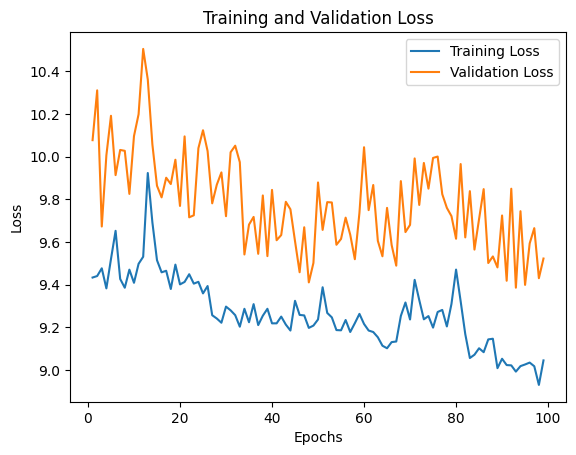

In [ ]:
plot_results(history_train[1:], history_val[1:])

#### run 5

In [ ]:
import torch.nn as nn

class Net (nn.Module):

  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(4, 32),
     nn.Tanh(),
     nn.Linear(32, 16),
     nn.Tanh(),
     nn.Linear(16, 8),
     nn.Tanh(),
     nn.Linear(8, 1)
    )

  def forward(self, x):
    return self.layers(x)

model = Net()
print(model)

Net(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train(model, train_dl, val_dl, optimizer, loss_fn, epochs = 200, device = device)

Epoch: 1, Training Loss: 1557.08, Validation Loss: 70.24
Epoch: 2, Training Loss: 73.13, Validation Loss: 70.28
Epoch: 3, Training Loss: 72.93, Validation Loss: 74.34
Epoch: 4, Training Loss: 72.96, Validation Loss: 70.93
Epoch: 5, Training Loss: 73.02, Validation Loss: 70.20
Epoch: 6, Training Loss: 72.67, Validation Loss: 76.83
Epoch: 7, Training Loss: 72.55, Validation Loss: 70.33
Epoch: 8, Training Loss: 72.62, Validation Loss: 72.22
Epoch: 9, Training Loss: 72.91, Validation Loss: 70.03
Epoch: 10, Training Loss: 72.81, Validation Loss: 70.67
Epoch: 11, Training Loss: 72.99, Validation Loss: 70.02
Epoch: 12, Training Loss: 72.82, Validation Loss: 70.58
Epoch: 13, Training Loss: 72.72, Validation Loss: 70.30
Epoch: 14, Training Loss: 72.75, Validation Loss: 70.01
Epoch: 15, Training Loss: 72.44, Validation Loss: 70.02
Epoch: 16, Training Loss: 72.71, Validation Loss: 70.94
Epoch: 17, Training Loss: 72.37, Validation Loss: 71.09
Epoch: 18, Training Loss: 72.57, Validation Loss: 70.25

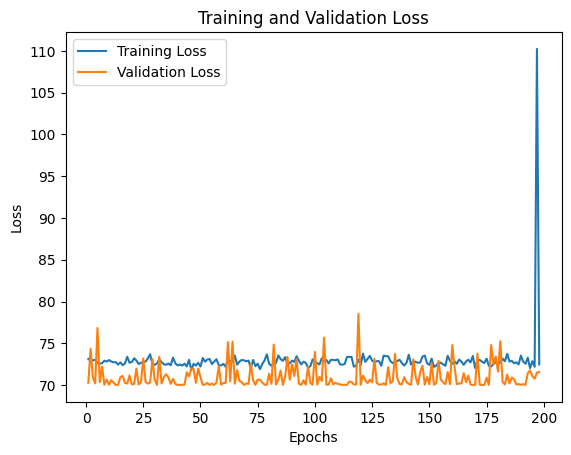

In [ ]:
plot_results(history_train[1:-1], history_val[1:-1])

# WEEK 2

#### looking at the extra datasets of week 2

In [ ]:
## wind data

data_wind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   u10     14600 non-null  float64       
 3   v10     14600 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 456.4 KB


In [ ]:
data_wind.head()

,day,lt,u10,v10
0,2017-01-01,1,-0.269521,0.207275
1,2017-01-01,2,0.662405,-0.584869
2,2017-01-01,3,-0.955972,0.489853
3,2017-01-01,4,-0.467423,0.755780
4,2017-01-01,5,-0.644524,0.294410


#### add wind speed column

since it is not repetitive between dataset, i don't need to define a function

In [ ]:
import numpy as np

data_wind['ws'] = np.sqrt (data_wind['u10']**2 + data_wind['v10']**2)

In [ ]:
data_wind['ws'][:5]

,ws
0,0.340007
1,0.883659
2,1.074168
3,0.888644
4,0.708582


In [ ]:
data_wind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   u10     14600 non-null  float64       
 3   v10     14600 non-null  float64       
 4   ws      14600 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 570.4 KB


In [ ]:
data_wind.describe()

,day,lt,u10,v10,ws
count,14600,14600.000000,14600.000000,14600.000000,14600.000000
mean,2017-12-31 12:00:00,10.500000,0.047042,0.410109,1.457658
min,2017-01-01 00:00:00,1.000000,-5.661072,-4.159942,0.035818
25%,2017-07-02 00:00:00,5.750000,-0.766917,-0.253003,0.901248
50%,2017-12-31 12:00:00,10.500000,-0.234054,0.583041,1.275899
75%,2018-07-02 00:00:00,15.250000,0.709847,1.076088,1.774812
max,2018-12-31 00:00:00,20.000000,8.994445,6.144852,9.250818
std,NaN,5.766479,1.230177,1.095078,0.870651


In [ ]:
# total cloud cover dataset

data_tcc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   0       14600 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 342.3 KB


In [ ]:
data_tcc.head()

,day,lt,0
0,2017-01-01,1,0.065216
1,2017-01-01,2,0.023865
2,2017-01-01,3,0.001862
3,2017-01-01,4,0.054871
4,2017-01-01,5,0.030518


In [ ]:
data_tcc.describe()

,day,lt,0
count,14600,14600.000000,14600.000000
mean,2017-12-31 12:00:00,10.500000,0.598568
min,2017-01-01 00:00:00,1.000000,0.000000
25%,2017-07-02 00:00:00,5.750000,0.193970
50%,2017-12-31 12:00:00,10.500000,0.721268
75%,2018-07-02 00:00:00,15.250000,0.982727
max,2018-12-31 00:00:00,20.000000,1.000006
std,NaN,5.766479,0.387853


#### change name of cloud cover from '0' to 'tcc'

I initially thought it is a string '0', turns out it was an integer.

In [ ]:
# data_tcc.rename(columns = {'0': 'tcc'}, inplace = True)
data_tcc = data_tcc.rename(columns = {0: 'tcc'})
data_tcc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   tcc     14600 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 342.3 KB


### merge all the datasets

#### change temp from K to Celcius first

In [ ]:
# all columns, including mean are included (this was rectified)
# mean is no longer included.. until we split using my_train_test_split

datast1.describe()

,day,lt,obs,hres,0,1,2,3,4,5,...,41,42,43,44,45,46,47,48,49,50
count,14600,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,...,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000
mean,2017-12-31 12:00:00,10.500000,284.120342,282.839539,281.587784,281.538208,281.576191,281.562506,281.551757,281.549114,...,281.563664,281.532886,281.560606,281.545092,281.524962,281.580849,281.533614,281.515879,281.514808,281.548489
min,2017-01-01 00:00:00,1.000000,260.950000,254.501434,250.756699,249.565094,250.599701,249.545914,249.647476,249.757126,...,251.697159,248.840012,250.248703,251.507126,251.453781,250.155487,248.722946,250.954620,250.868912,250.092102
25%,2017-07-02 00:00:00,5.750000,277.350000,276.026619,274.882599,274.836098,274.886047,274.795670,274.782288,274.812134,...,274.825562,274.892212,274.874893,274.815567,274.800217,274.878601,274.783035,274.783768,274.791931,274.835648
50%,2017-12-31 12:00:00,10.500000,283.950000,282.931519,281.489990,281.508423,281.550293,281.467163,281.496338,281.434570,...,281.528687,281.461792,281.482239,281.471680,281.475342,281.480713,281.465210,281.450195,281.461670,281.519531
75%,2018-07-02 00:00:00,15.250000,290.650000,289.695312,288.598328,288.513672,288.529480,288.508606,288.617065,288.494507,...,288.489685,288.515747,288.559570,288.536133,288.491882,288.630493,288.531677,288.533447,288.552795,288.531067
max,2018-12-31 00:00:00,20.000000,306.650000,304.977295,305.596191,306.161865,305.578125,305.805908,303.937744,305.419189,...,305.836426,305.578125,305.363281,305.937988,304.988037,305.122314,305.608398,305.088623,304.776855,306.155273
std,NaN,5.766479,8.392868,8.635700,8.887605,8.871771,8.832654,8.872437,8.864202,8.872627,...,8.833966,8.867187,8.844232,8.847349,8.830680,8.871467,8.837798,8.878706,8.868978,8.859339


In [ ]:
pd.concat?

In [ ]:
# to celcius.. remove day and lt and leave only the forecast features
datast1_k = datast1.drop(columns=['day', 'lt']).apply(lambda x: x-273.15)

# include day and lt
datast1_k = pd.concat([datast1[['day', 'lt']], datast1_k], axis = 1)

# take a look now, to see if the distribution makes sense for celcius
datast1_k.describe()

,day,lt,obs,hres,0,1,2,3,4,5,...,41,42,43,44,45,46,47,48,49,50
count,14600,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,...,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000,14600.000000
mean,2017-12-31 12:00:00,10.500000,10.970342,9.689539,8.437784,8.388208,8.426191,8.412506,8.401757,8.399114,...,8.413664,8.382886,8.410606,8.395092,8.374962,8.430849,8.383614,8.365879,8.364808,8.398489
min,2017-01-01 00:00:00,1.000000,-12.200000,-18.648566,-22.393301,-23.584906,-22.550299,-23.604086,-23.502524,-23.392874,...,-21.452841,-24.309988,-22.901297,-21.642874,-21.696219,-22.994513,-24.427054,-22.195380,-22.281088,-23.057898
25%,2017-07-02 00:00:00,5.750000,4.200000,2.876619,1.732599,1.686098,1.736047,1.645670,1.632288,1.662134,...,1.675562,1.742212,1.724893,1.665567,1.650217,1.728601,1.633035,1.633768,1.641931,1.685648
50%,2017-12-31 12:00:00,10.500000,10.800000,9.781519,8.339990,8.358423,8.400293,8.317163,8.346338,8.284570,...,8.378687,8.311792,8.332239,8.321680,8.325342,8.330713,8.315210,8.300195,8.311670,8.369531
75%,2018-07-02 00:00:00,15.250000,17.500000,16.545313,15.448328,15.363672,15.379480,15.358606,15.467065,15.344507,...,15.339685,15.365747,15.409570,15.386133,15.341882,15.480493,15.381677,15.383447,15.402795,15.381067
max,2018-12-31 00:00:00,20.000000,33.500000,31.827295,32.446191,33.011865,32.428125,32.655908,30.787744,32.269189,...,32.686426,32.428125,32.213281,32.787988,31.838037,31.972314,32.458398,31.938623,31.626855,33.005273
std,NaN,5.766479,8.392868,8.635700,8.887605,8.871771,8.832654,8.872437,8.864202,8.872627,...,8.833966,8.867187,8.844232,8.847349,8.830680,8.871467,8.837798,8.878706,8.868978,8.859339


In [ ]:
data_wind.merge?

In [ ]:
# i expect to see 59 columns

datast1_wind_tcc = datast1_k.merge(data_wind, how = 'inner', on = ['day', 'lt']).merge(data_tcc, how = 'inner', on = ['day', 'lt'])
datast1_wind_tcc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 59 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   obs     14600 non-null  float64       
 3   hres    14600 non-null  float64       
 4   0       14600 non-null  float64       
 5   1       14600 non-null  float64       
 6   2       14600 non-null  float64       
 7   3       14600 non-null  float64       
 8   4       14600 non-null  float64       
 9   5       14600 non-null  float64       
 10  6       14600 non-null  float64       
 11  7       14600 non-null  float64       
 12  8       14600 non-null  float64       
 13  9       14600 non-null  float64       
 14  10      14600 non-null  float64       
 15  11      14600 non-null  float64       
 16  12      14600 non-null  float64       
 17  13      14600 non-null  float64       
 18  14    

#### split the merged dataframe into train and test sets

Remember that the mean column is added by default when we use the `my_train_test_split` function

In [ ]:
datast1_combo_train, datast1_combo_test = my_train_test_split(datast1_wind_tcc)

/tmp/ipython-input-2741514633.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainset['mean'] = trainset.loc[:, ensemble_cols].mean(axis=1)
/tmp/ipython-input-2741514633.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testset['mean'] = testset.loc[:, ensemble_cols].mean(axis=1)


In [ ]:
datast1_combo_train.head()

,day,lt,obs,hres,0,1,2,3,4,5,...,46,47,48,49,50,u10,v10,ws,tcc,mean
0,2017-01-01,1,-4.9,-1.156348,-4.833350,-5.147314,-5.067236,-5.130957,-5.106299,-5.013525,...,-5.250830,-4.859473,-5.723242,-5.404395,-5.342932,-0.269521,0.207275,0.340007,0.065216,-5.168918
1,2017-01-01,2,-2.5,1.433252,3.605615,3.236475,4.379297,4.058984,3.473779,3.684717,...,3.686914,3.895654,3.355371,3.638574,3.714746,0.662405,-0.584869,0.883659,0.023865,3.730062
2,2017-01-01,3,-3.1,1.061182,-3.525977,-3.566016,-3.055273,-3.467871,-3.631445,-3.368262,...,-3.397070,-3.376562,-3.548926,-3.408545,-3.606299,-0.955972,0.489853,1.074168,0.001862,-3.290351
3,2017-01-01,4,-5.0,-2.043311,-6.131812,-6.337103,-6.404791,-6.045813,-7.369177,-6.555029,...,-6.739417,-6.204565,-6.475775,-5.911932,-6.670874,-0.467423,0.755780,0.888644,0.054871,-6.302762
4,2017-01-01,5,-5.0,-1.470068,-6.939001,-7.167090,-6.596350,-6.692847,-6.733069,-6.934058,...,-6.474799,-5.948035,-6.694434,-7.035071,-7.229712,-0.644524,0.294410,0.708582,0.030518,-6.656207


In [ ]:
datast1_combo_test.head()

,day,lt,obs,hres,0,1,2,3,4,5,...,46,47,48,49,50,u10,v10,ws,tcc,mean
7300,2018-01-01,1,5.2,3.261865,3.375635,2.983301,3.676660,3.487939,3.404932,3.672144,...,3.319238,3.844629,3.208368,3.389063,3.344873,-0.835099,1.347891,1.585623,1.000000,3.396716
7301,2018-01-01,2,9.2,6.567285,5.565820,5.637354,5.331201,4.852197,6.229150,6.190088,...,5.735254,5.580713,5.466455,5.357813,5.822900,1.326515,1.059969,1.697992,0.141418,5.548377
7302,2018-01-01,3,6.3,0.683252,-1.953467,-1.455420,-1.360937,-2.300391,-1.506201,-1.876807,...,-1.264746,-1.730566,-2.140234,-1.566748,-1.790137,-0.697772,1.020858,1.236542,0.999969,-1.595731
7303,2018-01-01,4,7.3,4.124414,3.379053,2.507959,3.916162,1.800073,2.980341,0.930750,...,2.933984,2.186182,3.700586,2.508936,2.091455,3.692329,3.246685,4.916733,0.977692,2.813789
7304,2018-01-01,5,5.4,2.990869,1.610742,1.175439,1.495508,1.634668,1.627588,0.584131,...,0.897943,1.616846,0.961816,1.182764,1.167383,2.900639,2.286521,3.693492,0.754456,1.298085


#### save the train and test sets with all features

In [ ]:
import os

datast1_combo_train.to_csv(os.path.join(PATH_DATA, 'data1_combo_train.csv'), index=False)
datast1_combo_test.to_csv(os.path.join(PATH_DATA, 'data1_combo_test.csv'), index=False)

### Continuation without defining functions

##### dataset preps

In [ ]:
# DEFINE THE COLUMNS I NEED
columns1 = ['lt', 'hres', '0', 'ws', 'tcc']
columns2 = [str(i) for i in np.arange(1,50)]

from sklearn.model_selection import train_test_split

# SPLIT INTO TRAIN AND TEST

X_train, X_val, y_train, y_val = train_test_split (datast1_combo_train.drop(columns = ['obs', 'day']), datast1_combo_train['obs'], test_size = 0.2, random_state = 7)

print(f'Splitting complete\n \
        Training set size: {X_train.shape[0]}\n \
        Validation set size: {X_val.shape[0]}\n')


# FEATURE EXTRACTION

# Input 1
X_train1 = X_train[columns1]
X_val1 = X_val[columns1]

# Input 2
X_train2 = X_train[columns2]
X_val2 = X_val[columns2]

print('Feature extraction is complete\n')
print(f"Features 1 before Normalization:\n \
        {X_train1.head()}\n") # iloc is used because the splitting may have messed with the index names

print(f"Features 2 before Normalization:\n \
        {X_train2.head()}\n") # iloc is used because the splitting may have messed with the index names


# NORMALIZE THE DATA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train1_norm = scaler.fit_transform(X_train1)
X_val1_norm = scaler.transform(X_val1)
mean1 = scaler.mean_
std1 = scaler.scale_

scaler = StandardScaler()
X_train2_norm = scaler.fit_transform(X_train2)
X_val2_norm = scaler.transform(X_val2)
mean2 = scaler.mean_
std2 = scaler.scale_

print('Normalization is complete\n')
print(f"Features 1 after Normalization:\n \
        {X_train1_norm[0:2, ]}") #standard scaler makes it a numpy array

print(f"Features 2 after Normalization:\n \
        {X_train1_norm[0:2, ]}") #standard scaler makes it a numpy array


# TO TENSOR DATASET

train_td = CustomDataset (X_train1_norm, X_train2_norm, y_train.to_numpy())
val_td = CustomDataset (X_val1_norm, X_val2_norm, y_val.to_numpy())

# TO DATALOADER

train_dl = DataLoader (train_td, batch_size = 64, shuffle = True)
val_dl = DataLoader (val_td, batch_size = 64, shuffle = True)

# confirmation
features1, features2, targets = next(iter(train_dl))

print(f'Conversion to DataLoader is complete\n \
  Feature shape per batch: {features1.shape}\n \
  Feature shape per batch: {features2.shape}\n \
  Target shape per batch: {targets.shape} \n \
  Total number of batches: {len(train_dl)}\n \
  Size of training set: {len(train_dl.dataset)}\n \
  Size of validation set: {len(val_dl.dataset)}')


Splitting complete
         Training set size: 5840
         Validation set size: 1460

Feature extraction is complete

Features 1 before Normalization:
               lt       hres          0        ws       tcc
5931  12   9.143457   6.932275  1.760072  0.669373
3739  20  18.101953  16.261621  1.885168  0.950714
5001   2  17.258447  18.084131  1.832636  0.822327
328    9 -14.261633 -18.336600  1.870801  0.329193
4186   7  23.394189  18.440088  0.887641  0.842133

Features 2 before Normalization:
                       1          2          3          4          5          6  \
5931   5.953027   8.316309   8.151514   6.308252   8.068018   7.419336   
3739  16.412988  15.097559  17.036768  15.719141  15.257227  15.465967   
5001  17.590967  17.170557  16.674219  17.078027  17.274561  16.867578   
328  -18.733923 -18.040503 -17.730627 -17.838690 -17.155936 -18.147635   
4186  21.743066  21.147119  19.594141  22.228906  21.014307  20.028223   

              7          8          9       

#### Experiment 3

##### run 1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiInputNet(nn.Module):
    def __init__(self, n_x1, n_x2):
        super().__init__()

        # This layer processes the second set of inputs
        # I put it as x2 since my current workflow supports it
        self.feature_extractor = nn.Linear(n_x2, 20)

        # These are the deeper layers that process the combined inputs
        self.deeper_layers = nn.Sequential(
            nn.Linear(20 + n_x1, 16),
            nn.Tanh(),
            nn.Linear(16, 8),
            nn.Tanh(),
            nn.Linear(8, 1) # Final output layer
        )

    # The forward pass now accepts two inputs
    def forward(self, x1, x2):
        # 1. Pass the first input through its feature extractor layer
        x2 = F.tanh(self.feature_extractor(x2))

        # 2. Concatenate the extracted features with the second input
        # We concatenate along dimension 1 (the feature dimension)
        x = torch.cat([x1, x2], dim=1)

        # 3. Pass the combined input through the deeper layers
        output = self.deeper_layers(x)

        return output

model = MultiInputNet(n_x1 = 5, n_x2 = 49)
print(model)

MultiInputNet(
  (feature_extractor): Linear(in_features=49, out_features=20, bias=True)
  (deeper_layers): Sequential(
    (0): Linear(in_features=25, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = nn.MSELoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train_multiple_inputs(model, train_dl, val_dl, optimizer, loss_fn, epochs = 200, device = device)

Epoch: 1, Training Loss: 26.40, Validation Loss: 12.17
Epoch: 2, Training Loss: 7.41, Validation Loss: 5.89
Epoch: 3, Training Loss: 5.62, Validation Loss: 6.05
Epoch: 4, Training Loss: 5.55, Validation Loss: 5.55
Epoch: 5, Training Loss: 5.11, Validation Loss: 6.18
Epoch: 6, Training Loss: 5.07, Validation Loss: 5.58
Epoch: 7, Training Loss: 4.97, Validation Loss: 5.53
Epoch: 8, Training Loss: 4.98, Validation Loss: 5.35
Epoch: 9, Training Loss: 5.06, Validation Loss: 5.76
Epoch: 10, Training Loss: 4.86, Validation Loss: 5.77
Epoch: 11, Training Loss: 4.72, Validation Loss: 5.20
Epoch: 12, Training Loss: 4.77, Validation Loss: 5.41
Epoch: 13, Training Loss: 4.72, Validation Loss: 5.49
Epoch: 14, Training Loss: 4.70, Validation Loss: 5.56
Epoch: 15, Training Loss: 4.61, Validation Loss: 5.50
Epoch: 16, Training Loss: 4.63, Validation Loss: 5.53
Epoch: 17, Training Loss: 4.75, Validation Loss: 5.16
Epoch: 18, Training Loss: 4.64, Validation Loss: 5.38
Epoch: 19, Training Loss: 4.60, Val

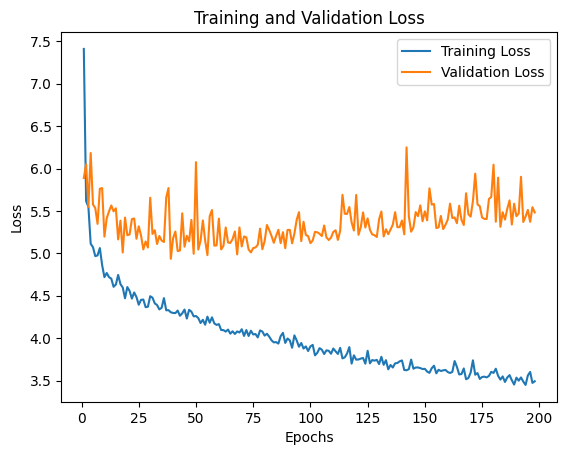

In [ ]:
plot_results(history_train[1:-1], history_val[1:-1])

#### Class Week 3

In [ ]:
datast1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14600 entries, 0 to 14599
Data columns (total 55 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   day     14600 non-null  datetime64[ns]
 1   lt      14600 non-null  int64         
 2   obs     14600 non-null  float64       
 3   hres    14600 non-null  float64       
 4   0       14600 non-null  float64       
 5   1       14600 non-null  float64       
 6   2       14600 non-null  float64       
 7   3       14600 non-null  float64       
 8   4       14600 non-null  float64       
 9   5       14600 non-null  float64       
 10  6       14600 non-null  float64       
 11  7       14600 non-null  float64       
 12  8       14600 non-null  float64       
 13  9       14600 non-null  float64       
 14  10      14600 non-null  float64       
 15  11      14600 non-null  float64       
 16  12      14600 non-null  float64       
 17  13      14600 non-null  float64       
 18  14    

In [ ]:
datast1.loc[0, :]

,0
day,2017-01-01 00:00:00
lt,1
obs,268.25
hres,271.993652
0,268.31665
1,268.002686
2,268.082764
3,268.019043
4,268.043701
5,268.136475


In [ ]:
# data_hist = datast1.drop(columns = ['day', 'lt'])

# i = 0
# for idx, row in data_hist.iterrows():

#   row_sort = row.sort_values()
#   obs_index_in_sort = row_sort.index.get_loc('obs')
#   row['rank_obs'] = obs_index_in_sort

#   data_hist[idx, :] = row


### Lab Week 3

In [ ]:
from scipy.stats import norm

In [ ]:
norm?

In [ ]:
def crps(y_pred, y_true):

  import numpy as np

  mu = y_pred[:, 0]
  std = y_pred[:, 1]
  pdf = norm.pdf(loc = 0, scale = 1)
  cdf = norm.cdf(loc = 0, scale = 1)

  stand = (y_true - mu)/std
  part_1 = stand * (2*cdf*stand - 1)
  part_2 = 2 * pdf * stand - (1/np.sqrt(np.pi))

  return std * (part_1 + part_2)

# WEEK 3&4&5 WORKSPACE

### QUESTIONS, EXPERIMENTS AND NOTES (TASK 2)

**Task**: Make probabilistic forecasts (distribution) and try to imporove on the loss

We consider the first dataset only (for Bregenze) for all experiments here too. We load the train and test datasets that are saved in google drive. It has all the features combined.

---
---

**Experiment 1:** Used 'hres', '0', 'mean', 'tcc', 'ws', 'lt' as the features.

- This had the best performance on the test set with 1.21 crps
---

**Experiment 2:** Add the ensemble too as more features and see the improvement

- There was no improvement. It got worse!
---
---

** Experiment 3:** We used the day as a feature.

- It improved from the second experiment

**Further work**
- The use of an embedding layer for the lead time



## task 1: calculating ensemble CRPS for the bregenz test set

In [ ]:
# we changed the function to return 2 outputs
df_raw_crps, mean_raw_crps = enscrps(datast1_combo_test)

In [ ]:
print (mean_raw_crps)

2.3953437509627333


## task 2: define CRPS for distribution predictions

In [ ]:
from scipy.stats import norm

norm?

Object `norm` not found.


In [ ]:
from scipy.stats import norm

norm.pdf?

In [ ]:
pdf = norm.pdf(4, loc = 0, scale = 1)
cdf = norm.cdf(0, loc = 0, scale = 1)

print(pdf)
print(cdf)

0.00013383022576488537
0.5


In [ ]:
from scipy.stats import norm

def pred_crps(y_pred, y_true):

  '''y_pred is expected to be a 2d array
  y_true is just a one dimensional '''

  import numpy as np
  from math import pi, sqrt

  mu = y_pred[:, 0] #first column represents the mean
  sd = y_pred[:, 1] #second column represents the standard deviation

  z = (y_true - mu)/sd # the true values standardized with respect to the actual distribution

  pdf = norm.pdf(z) # by default is standard normal
  cdf = norm.cdf(z)

  part_1 = z * (2*cdf - 1)
  part_2 = 2*pdf - (1/sqrt(pi))

  crps = sd * (part_1 + part_2)

  return crps

In [ ]:
a = np.random.randn(3,2)
a_1 = a[:,0]
print (a_1.shape)
print (a)

(3,)
[[ 0.50351526 -0.57587934]
 [-0.7142374   2.02001056]
 [-0.88403645  1.31016721]]


In [ ]:
# confirm if it works.

y_true = datast1_combo_test['obs']
y_predict = np.random.randn(datast1_combo_test.shape[0], 2)

crps = pred_crps(y_predict, y_true)

print(crps.mean())

0.14702480402869544


## task 3: define a pytorch loss function

In [ ]:
# import torch
# import torch.nn as nn
# import math
# # import torch.nn.functional as F

# class CRPSLoss(nn.Module): #inherit from nn.Module, just like with model definition

#     """
#     This class implements the Continuous Ranked Probability Score (CRPS) for a predicted
#     Normal distribution, designed to be used as a loss function in PyTorch.
#     """

#     def __init__(self, reduction = 'mean'):
#         # Initialize the parent nn.Module class
#         super().__init__()

#         # Check if the user has provided a valid reduction type
#         if reduction not in ['mean', 'sum', 'none']:
#             raise ValueError(f"{reduction} is not valid, choose from 'mean', 'sum' or 'none'. ")

#         self.reduction = reduction

#     def forward(self, y_pred, y_true):

#         """
#         This is the core method that calculates the loss.

#         Args:
#             y_pred (torch.Tensor): The model's prediction, with shape [batch_size, 2].
#                                    Column 0 is the predicted mean (mu).
#                                    Column 1 is the raw output for the standard deviation (std).
#             y_true (torch.Tensor): The true observed values, with shape [batch_size].
#         """

#         # Ensure y_true has the same shape as the predictions for broadcasting
#         # using y_true[:, 0] may have returned a tensor with shape (4,).. if tensors behave like arrays

#         y_true = y_true.view(-1, 1)

#         # Extract the predicted mean (mu) from the first column of y_pred
#         mu = y_pred[:, 0].unsqueeze(1) #unsqueeze adds a dimension 1st dimension

#         # Extract the raw output for the standard deviation from the second column
#         std_raw = y_pred[:, 1].unsqueeze(1)

#         # we skipped this softplus coz we will include it in model class
#         # The standard deviation must be positive. A softplus function is a smooth
#         # approximation of ReLU and ensures the output is always positive and non-zero.
#         # This is a crucial step for numerical stability.
#         # std = F.softplus(std_raw)

#         # Calculate the standardized value (z-score)
#         z = (y_true - mu) / std_raw

#         # Calculate the PDF of the standard normal distribution at z
#         # Formula: exp(-z^2 / 2) / sqrt(2 * pi)
#         pdf = torch.exp(-z**2 / 2) / math.sqrt(2 * math.pi)

#         # Calculate the CDF of the standard normal distribution at z
#         # The formula is 0.5 * (1 + erf(z / sqrt(2))), where erf is the error function.
#         cdf = 0.5 * (1 + torch.erf(z / math.sqrt(2)))

#         # Implement the closed-form CRPS formula for a Normal distribution
#         # from your provided image
#         part_1 = z * (2 * cdf - 1)
#         part_2 = 2 * pdf - (1 / math.sqrt(math.pi))
#         crps_tensor = std_raw * (part_1 + part_2)

#         # Apply the specified reduction at the end
#         if self.reduction == 'mean':
#             return crps_tensor.mean()
#         elif self.reduction == 'sum':
#             return crps_tensor.sum()
#         else:
#             return crps_tensor

In [ ]:
# check of the loss function

a = torch.randn(4, 2)
b = torch.randn(4)

print(a)
print(b)

l = CRPSLoss(reduction = 'sum')
print(l(a, b))

tensor([[-0.1185, -0.0331],
        [ 0.9014, -1.3761],
        [-0.2820, -1.4281],
        [-0.1342, -1.3684]])
tensor([ 0.5138, -1.4143, -1.1689, -0.0663])
tensor(-3.0733)


## task 4: define a network to make probabilistic predictions

### Experiment 1

- I will use 'hres', '0', 'mean', 'tcc', 'ws', 'lt'

#### data preparation

In [ ]:
datast1_combo_train.head()

,day,lt,obs,hres,0,1,2,3,4,5,...,46,47,48,49,50,u10,v10,ws,tcc,mean
0,2017-01-01,1,-4.9,-1.156348,-4.833350,-5.147314,-5.067236,-5.130957,-5.106299,-5.013525,...,-5.250830,-4.859473,-5.723242,-5.404395,-5.342932,-0.269521,0.207275,0.340007,0.065216,-5.168918
1,2017-01-01,2,-2.5,1.433252,3.605615,3.236475,4.379297,4.058984,3.473779,3.684717,...,3.686914,3.895654,3.355371,3.638574,3.714746,0.662405,-0.584869,0.883659,0.023865,3.730062
2,2017-01-01,3,-3.1,1.061182,-3.525977,-3.566016,-3.055273,-3.467871,-3.631445,-3.368262,...,-3.397070,-3.376562,-3.548926,-3.408545,-3.606299,-0.955972,0.489853,1.074168,0.001862,-3.290351
3,2017-01-01,4,-5.0,-2.043311,-6.131812,-6.337103,-6.404791,-6.045813,-7.369177,-6.555029,...,-6.739417,-6.204565,-6.475775,-5.911932,-6.670874,-0.467423,0.755780,0.888644,0.054871,-6.302762
4,2017-01-01,5,-5.0,-1.470068,-6.939001,-7.167090,-6.596350,-6.692847,-6.733069,-6.934058,...,-6.474799,-5.948035,-6.694434,-7.035071,-7.229712,-0.644524,0.294410,0.708582,0.030518,-6.656207


In [ ]:
# Feature selection, Split and Normalize data

features = ['hres', '0', 'mean', 'tcc', 'ws', 'lt']

X_train_norm, y_train, X_val_norm, y_val, mean_, sd_ = feature_selection_norm(datast1_combo_train,  features)

Splitting complete
         Training set size: 5840
         Validation set size: 1460

Feature extraction is complete

Rows before Normalization:
                    hres          0       mean       tcc        ws  lt
5931   9.143457   6.932275   7.006913  0.669373  1.760072  12
3739  18.101953  16.261621  16.055686  0.950714  1.885168  20

Normalization is complete

Rows after Normalization:
         [[ 0.00612563 -0.09465618 -0.08277139  0.15896284  0.31540515  0.26139396]
 [ 1.03347418  0.93823812  0.9319345   0.88631085  0.4616827   1.64868531]]


In [ ]:
train_dl, val_dl = to_data_loader(X_train_norm, y_train, X_val_norm, y_val)

Conversion to Tensor dataset is complete
   Type: <class 'torch.utils.data.dataset.TensorDataset'>

Conversion to DataLoader is complete
   Feature shape per batch: torch.Size([32, 6])
   Target shape per batch: torch.Size([32]) 
   Total number of batches: 183
   Size of training set: 5840
   Size of validation set: 1460


#### run 1

- 1st run here had a min train loss of 1.10 and min val loss of 1.17

In [ ]:
! pip install torchview

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchview

class Proba_Net (nn.Module):

  def __init__(self, n_features):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(n_features, 32),
     nn.Tanh(),
     nn.Linear(32, 16),
     nn.Tanh(),
     nn.Linear(16, 8),
     nn.Tanh(),
     nn.Linear(8, 2)
    )

  def forward(self, x):
    x = self.layers(x)

    mu = x[:,0].unsqueeze(1)
    std_raw = x[:,1].unsqueeze(1) #can be negative

    std = F.softplus(std_raw) #makes it strictly positive

    return torch.cat ((mu, std), dim = 1) # the tensors to be concatenated should be a tuple

model = Proba_Net(n_features = 6)
print(model)

# model_graph = torchview.draw_graph(model, input_size = (1, 1, 1, 6))
# model_graph.visual_graph

Proba_Net(
  (layers): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=2, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = CRPSLoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

history_train, history_val = train_multiple_out(model, train_dl, val_dl, optimizer, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 4.97, Validation Loss: 2.22
Epoch: 2, Training Loss: 1.79, Validation Loss: 1.53
Epoch: 3, Training Loss: 1.38, Validation Loss: 1.34
Epoch: 4, Training Loss: 1.27, Validation Loss: 1.24
Epoch: 5, Training Loss: 1.21, Validation Loss: 1.23
Epoch: 6, Training Loss: 1.19, Validation Loss: 1.21
Epoch: 7, Training Loss: 1.17, Validation Loss: 1.20
Epoch: 8, Training Loss: 1.17, Validation Loss: 1.21
Epoch: 9, Training Loss: 1.16, Validation Loss: 1.22
Epoch: 10, Training Loss: 1.16, Validation Loss: 1.39
Epoch: 11, Training Loss: 1.16, Validation Loss: 1.19
Epoch: 12, Training Loss: 1.15, Validation Loss: 1.23
Epoch: 13, Training Loss: 1.15, Validation Loss: 1.19
Epoch: 14, Training Loss: 1.14, Validation Loss: 1.21
Epoch: 15, Training Loss: 1.14, Validation Loss: 1.19
Epoch: 16, Training Loss: 1.14, Validation Loss: 1.23
Epoch: 17, Training Loss: 1.14, Validation Loss: 1.20
Epoch: 18, Training Loss: 1.14, Validation Loss: 1.21
Epoch: 19, Training Loss: 1.14, Valid

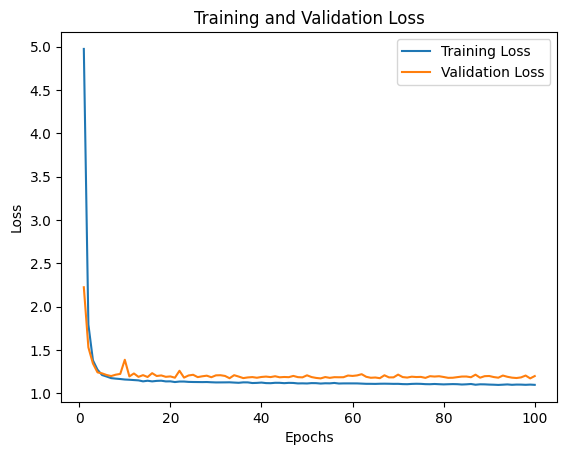

In [ ]:
plot_results(history_train, history_val)

### Prediction for test set

In [ ]:
datast1_combo_test.head()

,day,lt,obs,hres,0,1,2,3,4,5,...,46,47,48,49,50,u10,v10,ws,tcc,mean
0,2018-01-01,1,5.2,3.261865,3.375635,2.983301,3.676660,3.487939,3.404932,3.672144,...,3.319238,3.844629,3.208368,3.389063,3.344873,-0.835099,1.347891,1.585623,1.000000,3.396716
1,2018-01-01,2,9.2,6.567285,5.565820,5.637354,5.331201,4.852197,6.229150,6.190088,...,5.735254,5.580713,5.466455,5.357813,5.822900,1.326515,1.059969,1.697992,0.141418,5.548377
2,2018-01-01,3,6.3,0.683252,-1.953467,-1.455420,-1.360937,-2.300391,-1.506201,-1.876807,...,-1.264746,-1.730566,-2.140234,-1.566748,-1.790137,-0.697772,1.020858,1.236542,0.999969,-1.595731
3,2018-01-01,4,7.3,4.124414,3.379053,2.507959,3.916162,1.800073,2.980341,0.930750,...,2.933984,2.186182,3.700586,2.508936,2.091455,3.692329,3.246685,4.916733,0.977692,2.813789
4,2018-01-01,5,5.4,2.990869,1.610742,1.175439,1.495508,1.634668,1.627588,0.584131,...,0.897943,1.616846,0.961816,1.182764,1.167383,2.900639,2.286521,3.693492,0.754456,1.298085


In [ ]:
features

['hres', '0', 'mean', 'tcc', 'ws', 'lt']

In [ ]:
datast_ex4_test = datast1_combo_test[features]

# Normalize the test set using the training set mean and std
mean_ = mean_.reshape(-1,6)
sd_ = sd_.reshape(-1,6)

datast_ex4_test = (datast_ex4_test-mean_)/sd_

In [ ]:
datast_ex4_test.head()

,hres,0,mean,tcc,ws,lt
0,-0.668368,-0.488428,-0.487609,1.013729,0.111419,-1.646132
1,-0.289306,-0.245943,-0.246328,-1.205949,0.242814,-1.472720
2,-0.964080,-1.078437,-1.047449,1.013650,-0.296769,-1.299309
3,-0.569452,-0.488050,-0.552977,0.956055,4.006555,-1.125897
4,-0.699445,-0.683827,-0.722945,0.378927,2.576194,-0.952486


In [ ]:
datast_ex4_test.describe()

,hres,0,mean,tcc,ws,lt
count,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000,7300.000000
mean,0.138216,0.144314,0.146532,-0.056025,-0.071754,0.001277
std,0.978164,0.965679,0.965574,1.005474,1.040913,1.000008
min,-2.718396,-2.719285,-2.759759,-1.571556,-1.700801,-1.646132
25%,-0.667860,-0.620341,-0.627455,-1.131431,-0.713525,-0.822427
50%,0.177332,0.152945,0.158937,0.224920,-0.302716,0.001277
75%,0.932381,0.928136,0.935906,0.958837,0.269903,0.824981
max,2.528301,2.544167,2.520481,1.013745,7.662820,1.648685


In [ ]:
X_test_tensor = torch.tensor(datast_ex4_test.to_numpy(), dtype = torch.float32)
y_test_tensor = torch.tensor(datast1_combo_test['obs'].to_numpy(), dtype = torch.float32)

In [ ]:
X_test_td = TensorDataset(X_test_tensor, y_test_tensor)
X_test_dl = DataLoader(X_test_td, batch_size = 64, shuffle = False)

In [ ]:
X_test_dl.dataset

In [ ]:
model.eval?

In [ ]:
def make_predictions(model, test_data_loader, device):
    """
    Makes probabilistic predictions on a dataset using a trained model.
    """
    # Lists to store predictions and true values
    all_predictions = []
    all_targets = []

    # Set model to evaluation mode
    model.eval()

    # Use torch.no_grad() to disable gradient calculations
    with torch.no_grad():
        for batch, targets in test_data_loader:
            # Move data to the correct device
            input_data = batch.to(device)

            # Make a forward pass to get predictions
            predictions = model(input_data)

            # Move predictions and targets to CPU and store them
            all_predictions.append(predictions.cpu())
            all_targets.append(targets.cpu())

    # Concatenate all batches into single tensors
    final_predictions = torch.cat(all_predictions, dim=0)
    final_targets = torch.cat(all_targets, dim=0)

    return final_predictions, final_targets

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
predictions, targets = make_predictions(model, X_test_dl, device)

In [ ]:
predictions.shape

torch.Size([7300, 2])

In [ ]:
targets.shape

torch.Size([7300])

### loss for predictions

In [ ]:
# this was to test the crps function we defined using scipy
# crps = pred_crps(predictions, targets)
# crps.mean()

In [ ]:
crps_loss = CRPSLoss(reduction = 'none')

pred_crps_torch = crps_loss(predictions, targets)
print(pred_crps_torch.mean())

tensor(1.2140)


### Experiment 2

- I add the ensembles too and remove the mean

#### data preparation

In [ ]:
## SELECT FEATURES

features_1 = ['hres', 'tcc', 'ws', 'lt']
features_2 = [str(i) for i in range(51)]

features = features_1 + features_2

## NORMALIZE
X_train_norm, y_train, X_val_norm, y_val, mean_, sd_ = feature_selection_norm(datast1_combo_train,  features)

## TO DATA LOADER
train_dl, val_dl = to_data_loader(X_train_norm, y_train, X_val_norm, y_val)


Splitting complete
         Training set size: 5840
         Validation set size: 1460

Feature extraction is complete

Rows before Normalization:
                    hres       tcc        ws  lt          0          1          2  \
5931   9.143457  0.669373  1.760072  12   6.932275   5.953027   8.316309   
3739  18.101953  0.950714  1.885168  20  16.261621  16.412988  15.097559   

              3          4          5  ...         41         42         43  \
5931   8.151514   6.308252   8.068018  ...   6.261133   6.427148   4.860498   
3739  17.036768  15.719141  15.257227  ...  15.372705  15.426172  15.659570   

             44         45         46         47         48        49  \
5931   8.088037   8.788477   5.426904   6.635889   7.569727   7.76333   
3739  17.296045  15.097070  13.950342  17.488916  15.150537  16.07876   

             50  
5931   7.140283  
3739  16.689844  

[2 rows x 55 columns]

Normalization is complete

Rows after Normalization:
         [[ 0.00612563  0.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
# import torchview

class Proba_Net (nn.Module):

  def __init__(self, n_features):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(n_features, 128),
     nn.Tanh(),
     nn.Linear(128, 64),
     nn.Tanh(),
     nn.Linear(64, 32),
     nn.Tanh(),
     nn.Linear(32, 16),
     nn.Tanh(),
     nn.Linear(16, 2)
    )

  def forward(self, x):
    x = self.layers(x)

    mu = x[:,0].unsqueeze(1)
    std_raw = x[:,1].unsqueeze(1) #can be negative

    std = F.softplus(std_raw) #makes it strictly positive

    return torch.cat ((mu, std), dim = 1) # the tensors to be concatenated should be a tuple

model = Proba_Net(n_features = 55)
print(model)

Proba_Net(
  (layers): Sequential(
    (0): Linear(in_features=55, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): Tanh()
    (8): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = CRPSLoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

path = './ex2_run1'
history_train, history_val = train_multiple_out_save(model, train_dl, val_dl, optimizer, path, loss_fn, epochs = 100, device = device)

Epoch: 1, Training Loss: 4.65, Validation Loss: 1.97
Epoch: 2, Training Loss: 1.72, Validation Loss: 1.45
Epoch: 3, Training Loss: 1.51, Validation Loss: 1.39
Epoch: 4, Training Loss: 1.46, Validation Loss: 1.39
Epoch: 5, Training Loss: 1.39, Validation Loss: 1.28
Epoch: 6, Training Loss: 1.32, Validation Loss: 1.26
Epoch: 7, Training Loss: 1.32, Validation Loss: 1.24
Epoch: 8, Training Loss: 1.29, Validation Loss: 1.40
Epoch: 9, Training Loss: 1.26, Validation Loss: 1.31
Epoch: 10, Training Loss: 1.25, Validation Loss: 1.38
Epoch: 11, Training Loss: 1.22, Validation Loss: 1.31
Epoch: 12, Training Loss: 1.24, Validation Loss: 1.34
Epoch: 13, Training Loss: 1.22, Validation Loss: 1.22
Epoch: 14, Training Loss: 1.21, Validation Loss: 1.26
Epoch: 15, Training Loss: 1.19, Validation Loss: 1.33
Epoch: 16, Training Loss: 1.22, Validation Loss: 1.24
Epoch: 17, Training Loss: 1.20, Validation Loss: 1.24
Epoch: 18, Training Loss: 1.18, Validation Loss: 1.36
Epoch: 19, Training Loss: 1.19, Valid

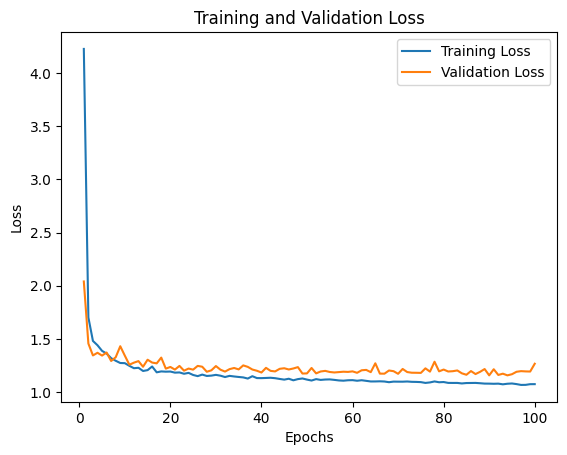

In [ ]:
plot_results(history_train, history_val)

#### prediction on test set

In [ ]:
# ensure that the class for the model is defined

model = torch.load('./ex2_run1', weights_only = False)

In [ ]:
datast_ex4_test = datast1_combo_test[features]

## Dataset before normalization
print('Test Dataset before normalization')
display(datast_ex4_test.head())

# Normalize the test set using the training set mean and std
mean_ = mean_.reshape(-1,55)
sd_ = sd_.reshape(-1,55)

print('Test Dataset after normalization')
datast_ex4_test = (datast_ex4_test-mean_)/sd_
display(datast_ex4_test.head())

# To data tensors
X_test_tensor = torch.tensor(datast_ex4_test.to_numpy(), dtype = torch.float32)
y_test_tensor = torch.tensor(datast1_combo_test['obs'].to_numpy(), dtype = torch.float32)

# To tensor dataset and dataloader
X_test_td = TensorDataset(X_test_tensor, y_test_tensor)
X_test_dl = DataLoader(X_test_td, batch_size = 64, shuffle = False)

# Predictions

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
predictions, targets = make_predictions(model, X_test_dl, device)


# Loss value for the prediction
crps_loss = CRPSLoss(reduction = 'none')

pred_crps_torch = crps_loss(predictions, targets)

print(f"Loss of predictions: {pred_crps_torch.mean()}")

Test Dataset before normalization


,hres,tcc,ws,lt,0,1,2,3,4,5,...,41,42,43,44,45,46,47,48,49,50
0,3.261865,1.000000,1.585623,1,3.375635,2.983301,3.676660,3.487939,3.404932,3.672144,...,3.870508,2.998438,3.265771,3.956201,3.215723,3.319238,3.844629,3.208368,3.389063,3.344873
1,6.567285,0.141418,1.697992,2,5.565820,5.637354,5.331201,4.852197,6.229150,6.190088,...,5.736963,5.416406,5.467920,5.892480,5.895654,5.735254,5.580713,5.466455,5.357813,5.822900
2,0.683252,0.999969,1.236542,3,-1.953467,-1.455420,-1.360937,-2.300391,-1.506201,-1.876807,...,-2.212744,-1.258887,-1.174170,-1.296484,-1.729102,-1.264746,-1.730566,-2.140234,-1.566748,-1.790137
3,4.124414,0.977692,4.916733,4,3.379053,2.507959,3.916162,1.800073,2.980341,0.930750,...,2.564081,2.979150,3.506738,2.614404,2.012048,2.933984,2.186182,3.700586,2.508936,2.091455
4,2.990869,0.754456,3.693492,5,1.610742,1.175439,1.495508,1.634668,1.627588,0.584131,...,1.476465,1.312646,1.526758,1.041406,0.656152,0.897943,1.616846,0.961816,1.182764,1.167383


Test Dataset after normalization


,hres,tcc,ws,lt,0,1,2,3,4,5,...,41,42,43,44,45,46,47,48,49,50
0,-0.668368,1.013729,0.111419,-1.646132,-0.488428,-0.532113,-0.455667,-0.472580,-0.484916,-0.452008,...,-0.433830,-0.525578,-0.500356,-0.422798,-0.504338,-0.495533,-0.434360,-0.500837,-0.481554,-0.491606
1,-0.289306,-1.205949,0.242814,-1.472720,-0.245943,-0.237202,-0.271394,-0.321514,-0.171582,-0.172824,...,-0.226692,-0.256581,-0.254828,-0.207229,-0.204762,-0.227618,-0.241575,-0.248726,-0.262946,-0.216609
2,-0.964080,1.013650,-0.296769,-1.299309,-1.078437,-1.025332,-1.016724,-1.113529,-1.029784,-1.067263,...,-1.108945,-0.999202,-0.995387,-1.007587,-1.057096,-1.003858,-1.053463,-1.097997,-1.031843,-1.061458
3,-0.569452,0.956055,4.006555,-1.125897,-0.488050,-0.584932,-0.428992,-0.659480,-0.532023,-0.755968,...,-0.578816,-0.527724,-0.473490,-0.572182,-0.638891,-0.538255,-0.618524,-0.445882,-0.579283,-0.630702
4,-0.699445,0.378927,2.576194,-0.952486,-0.683827,-0.732998,-0.698590,-0.677795,-0.682105,-0.794400,...,-0.699519,-0.713121,-0.694247,-0.747306,-0.790460,-0.764034,-0.681746,-0.751660,-0.726540,-0.733250


Loss of predictions: 1.240628719329834


### Experiment 3

In [ ]:
datast1_combo_train.head()

,day,lt,obs,hres,0,1,2,3,4,5,...,46,47,48,49,50,u10,v10,ws,tcc,mean
0,2017-01-01,1,-4.9,-1.156348,-4.833350,-5.147314,-5.067236,-5.130957,-5.106299,-5.013525,...,-5.250830,-4.859473,-5.723242,-5.404395,-5.342932,-0.269521,0.207275,0.340007,0.065216,-5.168918
1,2017-01-01,2,-2.5,1.433252,3.605615,3.236475,4.379297,4.058984,3.473779,3.684717,...,3.686914,3.895654,3.355371,3.638574,3.714746,0.662405,-0.584869,0.883659,0.023865,3.730062
2,2017-01-01,3,-3.1,1.061182,-3.525977,-3.566016,-3.055273,-3.467871,-3.631445,-3.368262,...,-3.397070,-3.376562,-3.548926,-3.408545,-3.606299,-0.955972,0.489853,1.074168,0.001862,-3.290351
3,2017-01-01,4,-5.0,-2.043311,-6.131812,-6.337103,-6.404791,-6.045813,-7.369177,-6.555029,...,-6.739417,-6.204565,-6.475775,-5.911932,-6.670874,-0.467423,0.755780,0.888644,0.054871,-6.302762
4,2017-01-01,5,-5.0,-1.470068,-6.939001,-7.167090,-6.596350,-6.692847,-6.733069,-6.934058,...,-6.474799,-5.948035,-6.694434,-7.035071,-7.229712,-0.644524,0.294410,0.708582,0.030518,-6.656207


### create new feature for day (for training set)

In [ ]:
datast1_combo_train['day'][:20].unique()

array(['2017-01-01'], dtype=object)

In [ ]:
day_year = []
for day in range(1, 365+1):
  for lt in range(1, 20+1):
    day_year.append(day)

datast1_combo_train['day_of_year'] = day_year

In [ ]:
datast1_combo_train['day_of_year'].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [ ]:
from math import pi, sin

datast1_combo_train['sin_day'] = datast1_combo_train['day_of_year'].apply(lambda x: 5*sin(pi*x/365)+5)

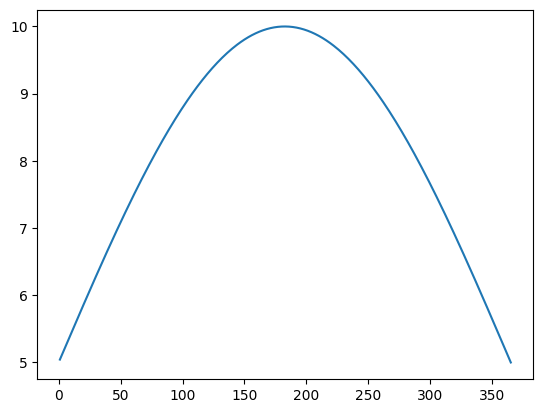

In [ ]:
import matplotlib.pyplot as plt

plt.plot(datast1_combo_train['day_of_year'], datast1_combo_train['sin_day'])
plt.show();

### create new feature for day (for test set)

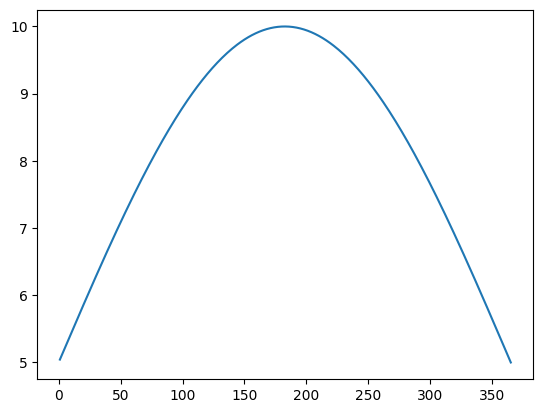

In [ ]:
datast1_combo_test['day_of_year'] = day_year

datast1_combo_test['sin_day'] = datast1_combo_test['day_of_year'].apply(lambda x: 5*sin(pi*x/365)+5)

plt.plot(datast1_combo_test['day_of_year'], datast1_combo_test['sin_day'])
plt.show();

###data preparation

In [ ]:
# Feature selection, Split and Normalize data

features = ['hres', '0', 'mean', 'tcc', 'ws', 'lt', 'sin_day']

X_train_norm, y_train, X_val_norm, y_val, mean_, sd_ = feature_selection_norm(datast1_combo_train,  features)

train_dl, val_dl = to_data_loader(X_train_norm, y_train, X_val_norm, y_val)

Splitting complete
         Training set size: 5840
         Validation set size: 1460

Feature extraction is complete

Rows before Normalization:
                    hres          0       mean       tcc        ws  lt   sin_day
5931   9.143457   6.932275   7.006913  0.669373  1.760072  12  7.762177
3739  18.101953  16.261621  16.055686  0.950714  1.885168  20  9.996250

Normalization is complete

Rows after Normalization:
         [[ 0.00612563 -0.09465618 -0.08277139  0.15896284  0.31540515  0.26139396
  -0.2750006 ]
 [ 1.03347418  0.93823812  0.9319345   0.88631085  0.4616827   1.64868531
   1.1755356 ]]
Conversion to Tensor dataset is complete
   Type: <class 'torch.utils.data.dataset.TensorDataset'>

Conversion to DataLoader is complete
   Feature shape per batch: torch.Size([32, 7])
   Target shape per batch: torch.Size([32]) 
   Total number of batches: 183
   Size of training set: 5840
   Size of validation set: 1460


### run 1

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchview

class Proba_Net (nn.Module):

  def __init__(self, n_features):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(n_features, 32),
     nn.Tanh(),
     nn.Linear(32, 16),
     nn.Tanh(),
     nn.Linear(16, 8),
     nn.Tanh(),
     nn.Linear(8, 2)
    )

  def forward(self, x):
    x = self.layers(x)

    mu = x[:,0].unsqueeze(1)
    std_raw = x[:,1].unsqueeze(1) #can be negative

    std = F.softplus(std_raw) #makes it strictly positive

    return torch.cat ((mu, std), dim = 1) # the tensors to be concatenated should be a tuple

model = Proba_Net(n_features = 7)
print(model)

# model_graph = torchview.draw_graph(model, input_size = (1, 1, 1, 6))
# model_graph.visual_graph

Proba_Net(
  (layers): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=2, bias=True)
  )
)


Epoch: 1, Training Loss: 5.17, Validation Loss: 2.23
Epoch: 2, Training Loss: 1.83, Validation Loss: 1.64
Epoch: 3, Training Loss: 1.39, Validation Loss: 1.29
Epoch: 4, Training Loss: 1.23, Validation Loss: 1.21
Epoch: 5, Training Loss: 1.18, Validation Loss: 1.17
Epoch: 6, Training Loss: 1.15, Validation Loss: 1.16
Epoch: 7, Training Loss: 1.14, Validation Loss: 1.18
Epoch: 8, Training Loss: 1.13, Validation Loss: 1.21
Epoch: 9, Training Loss: 1.12, Validation Loss: 1.18
Epoch: 10, Training Loss: 1.12, Validation Loss: 1.19
Epoch: 11, Training Loss: 1.11, Validation Loss: 1.16
Epoch: 12, Training Loss: 1.10, Validation Loss: 1.15
Epoch: 13, Training Loss: 1.10, Validation Loss: 1.18
Epoch: 14, Training Loss: 1.10, Validation Loss: 1.14
Epoch: 15, Training Loss: 1.09, Validation Loss: 1.15
Epoch: 16, Training Loss: 1.09, Validation Loss: 1.16
Epoch: 17, Training Loss: 1.09, Validation Loss: 1.13
Epoch: 18, Training Loss: 1.08, Validation Loss: 1.11
Epoch: 19, Training Loss: 1.08, Valid

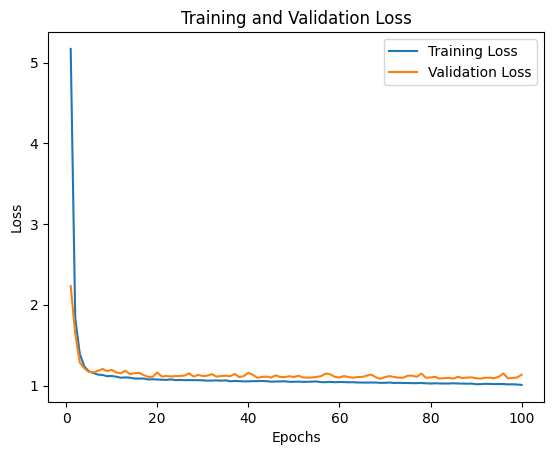

In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = CRPSLoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

save_path = './ex3_run1.pt'
history_train, history_val = train_multiple_out_save(model, train_dl, val_dl, optimizer, save_path, loss_fn, epochs = 100, device = device)

plot_results(history_train, history_val)

### prediction on test set

In [ ]:
# ensure that the class for the model is defined

model = torch.load('./ex3_run1.pt', weights_only = False)

In [ ]:
datast_ex4_test = datast1_combo_test[features]

## Dataset before normalization
print('Test Dataset before normalization')
display(datast_ex4_test.head())

# Normalize the test set using the training set mean and std
mean_ = mean_.reshape(-1,len(features))
sd_ = sd_.reshape(-1,len(features))

print('Test Dataset after normalization')
datast_ex4_test = (datast_ex4_test-mean_)/sd_
display(datast_ex4_test.head())

# To data tensors
X_test_tensor = torch.tensor(datast_ex4_test.to_numpy(), dtype = torch.float32)
y_test_tensor = torch.tensor(datast1_combo_test['obs'].to_numpy(), dtype = torch.float32)

# To tensor dataset and dataloader
X_test_td = TensorDataset(X_test_tensor, y_test_tensor)
X_test_dl = DataLoader(X_test_td, batch_size = 64, shuffle = False)

# Predictions
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
predictions, targets = make_predictions(model, X_test_dl, device)


# Loss value for the prediction
crps_loss = CRPSLoss(reduction = 'none')

pred_crps_torch = crps_loss(predictions, targets)

print(f"Loss of predictions: {pred_crps_torch.mean()}")

Test Dataset before normalization


,hres,0,mean,tcc,ws,lt,sin_day
0,3.261865,3.375635,3.396716,1.000000,1.585623,1,5.043035
1,6.567285,5.565820,5.548377,0.141418,1.697992,2,5.043035
2,0.683252,-1.953467,-1.595731,0.999969,1.236542,3,5.043035
3,4.124414,3.379053,2.813789,0.977692,4.916733,4,5.043035
4,2.990869,1.610742,1.298085,0.754456,3.693492,5,5.043035


Test Dataset after normalization


,hres,0,mean,tcc,ws,lt,sin_day
0,-0.668368,-0.488428,-0.487609,1.013729,0.111419,-1.646132,-2.040481
1,-0.289306,-0.245943,-0.246328,-1.205949,0.242814,-1.472720,-2.040481
2,-0.964080,-1.078437,-1.047449,1.013650,-0.296769,-1.299309,-2.040481
3,-0.569452,-0.488050,-0.552977,0.956055,4.006555,-1.125897,-2.040481
4,-0.699445,-0.683827,-0.722945,0.378927,2.576194,-0.952486,-2.040481


Loss of predictions: 1.2205640077590942


### run 2

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torchview

class Proba_Net (nn.Module):

  def __init__(self, n_features):
    super().__init__()

    self.layers = nn.Sequential(
     nn.Linear(n_features, 32),
     nn.BatchNorm1d(32),
     nn.Tanh(),

     nn.Linear(32, 16),
     nn.BatchNorm1d(16),
     nn.Tanh(),

     nn.Linear(16, 8),
     nn.BatchNorm1d(8),
     nn.Tanh(),

     nn.Linear(8, 2)
    )

  def forward(self, x):
    x = self.layers(x)

    mu = x[:,0].unsqueeze(1)
    std_raw = x[:,1].unsqueeze(1) #can be negative

    std = F.softplus(std_raw) #makes it strictly positive

    return torch.cat ((mu, std), dim = 1) # the tensors to be concatenated should be a tuple

model = Proba_Net(n_features = 7)
print(model)

# model_graph = torchview.draw_graph(model, input_size = (1, 1, 1, 6))
# model_graph.visual_graph

Proba_Net(
  (layers): Sequential(
    (0): Linear(in_features=7, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Tanh()
    (9): Linear(in_features=8, out_features=2, bias=True)
  )
)


Epoch: 1, Training Loss: 5.73, Validation Loss: 2.22
Epoch: 2, Training Loss: 2.12, Validation Loss: 1.66
Epoch: 3, Training Loss: 1.78, Validation Loss: 1.49
Epoch: 4, Training Loss: 1.68, Validation Loss: 1.46
Epoch: 5, Training Loss: 1.61, Validation Loss: 1.39
Epoch: 6, Training Loss: 1.52, Validation Loss: 1.36
Epoch: 7, Training Loss: 1.57, Validation Loss: 1.26
Epoch: 8, Training Loss: 1.52, Validation Loss: 1.25
Epoch: 9, Training Loss: 1.49, Validation Loss: 1.35
Epoch: 10, Training Loss: 1.46, Validation Loss: 1.31
Epoch: 11, Training Loss: 1.41, Validation Loss: 1.34
Epoch: 12, Training Loss: 1.42, Validation Loss: 1.20
Epoch: 13, Training Loss: 1.43, Validation Loss: 1.21
Epoch: 14, Training Loss: 1.41, Validation Loss: 1.31
Epoch: 15, Training Loss: 1.43, Validation Loss: 1.20
Epoch: 16, Training Loss: 1.43, Validation Loss: 1.19
Epoch: 17, Training Loss: 1.38, Validation Loss: 1.20
Epoch: 18, Training Loss: 1.39, Validation Loss: 1.19
Epoch: 19, Training Loss: 1.41, Valid

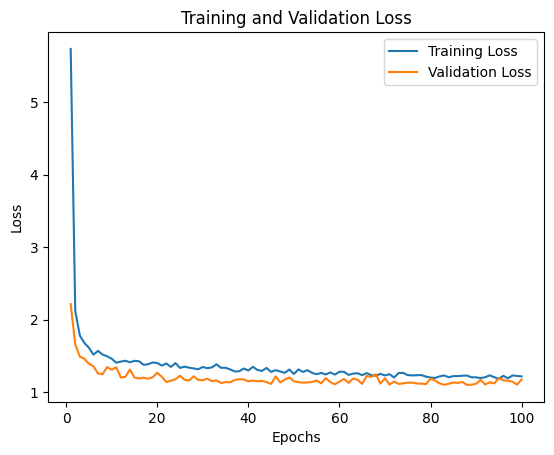

In [ ]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr = 0.001)
loss_fn = CRPSLoss(reduction = 'sum')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

save_path = './ex3_run2.pt'
history_train, history_val = train_multiple_out_save(model, train_dl, val_dl, optimizer, save_path, loss_fn, epochs = 100, device = device)

plot_results(history_train, history_val)

### prediction on test set

In [ ]:
# ensure that the class for the model is defined

model = torch.load('./ex3_run2.pt', weights_only = False)

In [ ]:
datast_ex4_test = datast1_combo_test[features]

## Dataset before normalization
print('Test Dataset before normalization')
display(datast_ex4_test.head())

# Normalize the test set using the training set mean and std
mean_ = mean_.reshape(-1,len(features))
sd_ = sd_.reshape(-1,len(features))

print('Test Dataset after normalization')
datast_ex4_test = (datast_ex4_test-mean_)/sd_
display(datast_ex4_test.head())

# To data tensors
X_test_tensor = torch.tensor(datast_ex4_test.to_numpy(), dtype = torch.float32)
y_test_tensor = torch.tensor(datast1_combo_test['obs'].to_numpy(), dtype = torch.float32)

# To tensor dataset and dataloader
X_test_td = TensorDataset(X_test_tensor, y_test_tensor)
X_test_dl = DataLoader(X_test_td, batch_size = 64, shuffle = False)

# Predictions
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
predictions, targets = make_predictions(model, X_test_dl, device)


# Loss value for the prediction
crps_loss = CRPSLoss(reduction = 'none')

pred_crps_torch = crps_loss(predictions, targets)

print(f"Loss of predictions: {pred_crps_torch.mean()}")

Test Dataset before normalization


,hres,0,mean,tcc,ws,lt,sin_day
0,3.261865,3.375635,3.396716,1.000000,1.585623,1,5.043035
1,6.567285,5.565820,5.548377,0.141418,1.697992,2,5.043035
2,0.683252,-1.953467,-1.595731,0.999969,1.236542,3,5.043035
3,4.124414,3.379053,2.813789,0.977692,4.916733,4,5.043035
4,2.990869,1.610742,1.298085,0.754456,3.693492,5,5.043035


Test Dataset after normalization


,hres,0,mean,tcc,ws,lt,sin_day
0,-0.668368,-0.488428,-0.487609,1.013729,0.111419,-1.646132,-2.040481
1,-0.289306,-0.245943,-0.246328,-1.205949,0.242814,-1.472720,-2.040481
2,-0.964080,-1.078437,-1.047449,1.013650,-0.296769,-1.299309,-2.040481
3,-0.569452,-0.488050,-0.552977,0.956055,4.006555,-1.125897,-2.040481
4,-0.699445,-0.683827,-0.722945,0.378927,2.576194,-0.952486,-2.040481


Loss of predictions: 1.2460860013961792


# WEEK 4 LAB

## task 1: plotting crps of ensemble and predictions wrt the lead time

In [ ]:
pred_crps_torch.shape

torch.Size([7300, 1])

In [ ]:
# # re-run the raw crps function, and save the dataframe

raw_crps_df, raw_crps_mean = enscrps(datast1_combo_test)
raw_crps_df.head()

,day,lt,crps_raw
0,2018-01-01,1,1.672720
1,2018-01-01,2,3.480923
2,2018-01-01,3,7.697732
3,2018-01-01,4,4.099254
4,2018-01-01,5,3.902443


In [ ]:
# add the crps for the predictions with the dataframe above

crps_df = raw_crps_df.copy()
crps_df['pred_crps'] = pred_crps_torch.numpy()
crps_df.head()

,day,lt,crps_raw,pred_crps
0,2018-01-01,1,1.672720,0.409070
1,2018-01-01,2,3.480923,0.606167
2,2018-01-01,3,7.697732,2.878736
3,2018-01-01,4,4.099254,0.846970
4,2018-01-01,5,3.902443,0.485805


In [ ]:
# confirmation that everything is okay

print(crps_df['crps_raw'].mean())
print(crps_df['pred_crps'].mean())

2.3953437509627333
1.213988


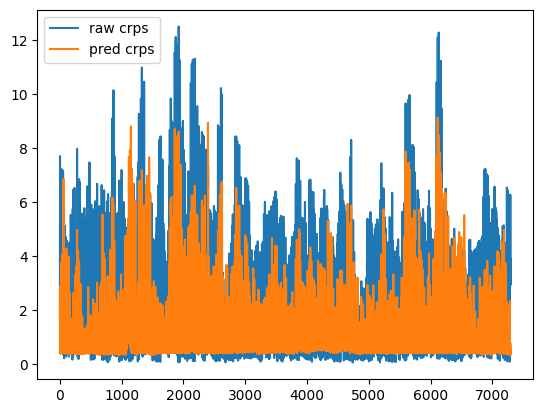

In [ ]:
import matplotlib.pyplot as plt

x = range(len(crps_df))
plt.plot(x, crps_df['crps_raw'], label = 'raw crps')
plt.plot(x, crps_df['pred_crps'], label = 'pred crps')
plt.legend()
plt.show()

In [ ]:
crps_list = []

for lt in range(1, 120):

  crps_lt = crps_df[crps_df['lt']==lt]

  dict_crps = {
  'crps_raw_mean': crps_lt['crps_raw'].mean(),
  'crps_pred_mean': crps_lt['pred_crps'].mean()
  }

  crps_list.append(dict_crps)

df_crps_mean = pd.DataFrame(crps_list)
df_crps_mean.head()

,crps_raw_mean,crps_pred_mean
0,2.019152,0.942822
1,1.534531,1.248447
2,2.392322,1.050145
3,3.291386,1.217863
4,2.255139,1.051110


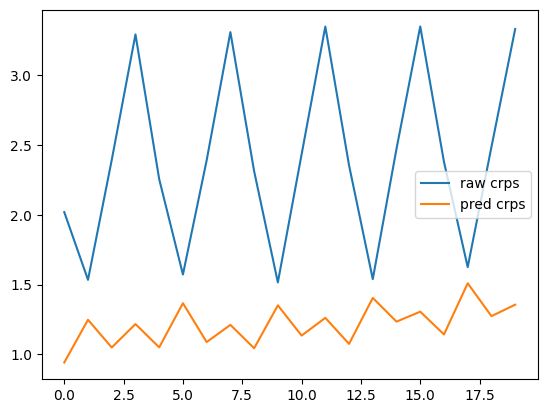

In [ ]:
import matplotlib.pyplot as plt

x = range(len(df_crps_mean))
plt.plot(x, df_crps_mean['crps_raw_mean'], label = 'raw crps')
plt.plot(x, df_crps_mean['crps_pred_mean'], label = 'pred crps')
plt.legend()
plt.show();

## task 2: plotting the coverage of the predictions and ensembles

- here we calculate the proportion of forecasts that included the observations within their predictions. we calculate it for the ensemble and for the predictions.

- for the ensemble, we use the 1s and 0s and just calculate the mean. it should be an easy implementation

- for the predicted value, we use the quantiles and check for the mid-part (1-alpha)% part.. i.e the part with that much probability

- the nominal value (dashed line) in figure, it is just a straight line 50/52

In [ ]:
# for lt in range(1, 120):

#   crps_lt = crps_df[crps_df['lt']==lt]

#   for idx, row in crps_lt.iterrows():
#     min_ens =
#     if row['obs']

#   dict_crps = {
#   'crps_raw_mean': crps_lt['crps_raw'].mean(),
#   'crps_pred_mean': crps_lt['pred_crps'].mean()
#   }

#   crps_list.append(dict_crps)

# df_crps_mean = pd.DataFrame(crps_list)
# df_crps_mean.head()

In [ ]:
np.where?

In [ ]:
import numpy as np
import pandas as pd


df_sample = pd.DataFrame({
    '0': [0.1, 0.2, 0.3, 0.4, 0.5],
    '1': [0.2, 0.3, 0.4, 0.5, 0.6],
    '2': [0.3, 0.4, 0.5, 0.6, 0.7],
    'obs': [2, 0.1, 0.8, 0.5, 0.1]
})

display(df_sample.head())

ens = [str(i) for i in range(3)]

df_sample['ens_min'] = df_sample[ens].min(axis = 1)
df_sample['ens_max'] = df_sample[ens].max(axis = 1)

display(df_sample.head())

df_sample['in_out'] = np.where((df_sample['ens_min'] < df_sample['obs']) & (df_sample['obs'] < df_sample['ens_max']), 1, 0)

display(df_sample.head())


,0,1,2,obs
0,0.1,0.2,0.3,2.0
1,0.2,0.3,0.4,0.1
2,0.3,0.4,0.5,0.8
3,0.4,0.5,0.6,0.5
4,0.5,0.6,0.7,0.1


,0,1,2,obs,ens_min,ens_max
0,0.1,0.2,0.3,2.0,0.1,0.3
1,0.2,0.3,0.4,0.1,0.2,0.4
2,0.3,0.4,0.5,0.8,0.3,0.5
3,0.4,0.5,0.6,0.5,0.4,0.6
4,0.5,0.6,0.7,0.1,0.5,0.7


,0,1,2,obs,ens_min,ens_max,in_out
0,0.1,0.2,0.3,2.0,0.1,0.3,0
1,0.2,0.3,0.4,0.1,0.2,0.4,0
2,0.3,0.4,0.5,0.8,0.3,0.5,0
3,0.4,0.5,0.6,0.5,0.4,0.6,1
4,0.5,0.6,0.7,0.1,0.5,0.7,0


In [ ]:
import numpy as np
import pandas as pd


df_sample = pd.DataFrame({
    '0': [0.1, 0.2, 0.3, 0.4, 0.5],
    '1': [0.2, 0.3, 0.4, 0.5, 0.6],
    '2': [0.3, 0.4, 0.5, 0.6, 0.7],
    'obs': [2, 0.1, 0.8, 0.5, 0.1]
})

display(df_sample.head())

ens = [str(i) for i in range(3)]

df_sample['ens_min'] = df_sample[ens].min(axis = 1)
df_sample['ens_max'] = df_sample[ens].max(axis = 1)

display(df_sample.head())

df_sample['in_out'] = np.where((np.less(df_sample['ens_min'], df_sample['obs'])) & (np.less(df_sample['obs'], df_sample['ens_max'])), 1, 0)

display(df_sample.head())


,0,1,2,obs
0,0.1,0.2,0.3,2.0
1,0.2,0.3,0.4,0.1
2,0.3,0.4,0.5,0.8
3,0.4,0.5,0.6,0.5
4,0.5,0.6,0.7,0.1


,0,1,2,obs,ens_min,ens_max
0,0.1,0.2,0.3,2.0,0.1,0.3
1,0.2,0.3,0.4,0.1,0.2,0.4
2,0.3,0.4,0.5,0.8,0.3,0.5
3,0.4,0.5,0.6,0.5,0.4,0.6
4,0.5,0.6,0.7,0.1,0.5,0.7


,0,1,2,obs,ens_min,ens_max,in_out
0,0.1,0.2,0.3,2.0,0.1,0.3,0
1,0.2,0.3,0.4,0.1,0.2,0.4,0
2,0.3,0.4,0.5,0.8,0.3,0.5,0
3,0.4,0.5,0.6,0.5,0.4,0.6,1
4,0.5,0.6,0.7,0.1,0.5,0.7,0


In [ ]:
# df_sample['ens_min'] < df_sample['obs']
np.less(df_sample['ens_min'], df_sample['obs'])

,0
0,True
1,False
2,True
3,True
4,False


In [ ]:
import numpy as np

def coverage_ens(data):

  ens = [str(i) for i in range(51)]

  data['ens_min'] = data[ens].min(axis = 1)
  data['ens_max'] = data[ens].max(axis = 1)

  data['in_out'] = np.where((np.less(data['ens_min'], data['obs'])) & (np.less(data['obs'], data['ens_max'])), 1, 0)
  data['width'] = data['ens_max'] - data['ens_min']

  # initialize proportion of observations inside the ensemble
  coverage = []
  width = []
  for lt in range(1, 21):
    prop_lt = data['in_out'][data['lt'] == lt].mean(axis = 0)
    width_lt = data['width'][data['lt'] == lt].mean(axis = 0)
    coverage.append(prop_lt)
    width.append(width_lt)

  return coverage, width

In [ ]:
import scipy.stats as sp

In [ ]:
sp.norm.ppf?

In [ ]:
import scipy.stats as sp
import numpy as np

def coverage_pred(data, predictions, alpha):

  # i initially thought we will be computing the z value corresponding to the symmetric area
  # this would have meant that the left area is -z1 and the right is z1
  # but using inside as (1-alpha/2) instead of (1-alpha) seems to be off!

  tail = alpha/2 #the tail area of normal distribution
  inside = 1- alpha/2 #the middle area

  #extract the mean and std and add them as columns
  data['mean_pred'] =  predictions[:,0]
  data['std_pred'] =  predictions[:,1]

  # get the lower and upper quantiles (which will be different i suppose, not just one being the neg of the other)
  data['lower'] = sp.norm.ppf(tail, loc = data['mean_pred'], scale = data['std_pred'])
  data['upper'] = sp.norm.ppf(inside, loc = data['mean_pred'], scale = data['std_pred'])
  data['width'] = data['upper'] - data['lower']

  data['in_out'] = np.where((data['lower'] < data['obs']) & (data['obs']< data['upper']), 1, 0)

  coverage = []
  width = []
  for lt in range(1, 21):
    prop_lt = data['in_out'][data['lt'] == lt].mean(axis = 0)
    width_lt = data['width'][data['lt'] == lt].mean(axis = 0)
    coverage.append(prop_lt)
    width.append(width_lt)

  return coverage, width

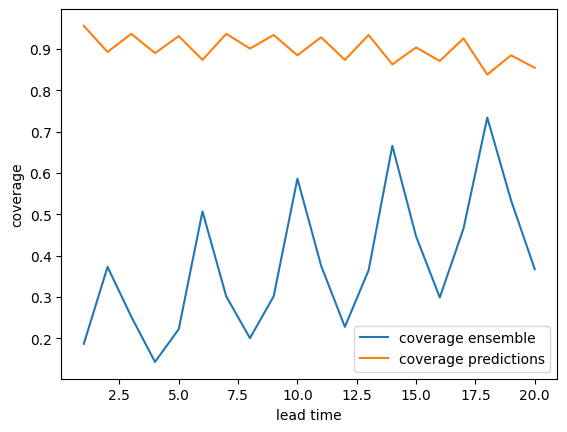

In [ ]:
import matplotlib.pyplot as plt

# plot the coverage for ensemble and predictions at the same graph

cov_ens, width_ens = coverage_ens(datast1_combo_test)
cov_pred, width_pred = coverage_pred(datast1_combo_test, predictions, 0.05)

x = range(1, 21)

# Coverage
plt.plot(x, cov_ens, label = 'coverage ensemble')
plt.plot(x, cov_pred, label = 'coverage predictions')
plt.legend()
plt.xlabel('lead time')
plt.ylabel('coverage')
plt.show();


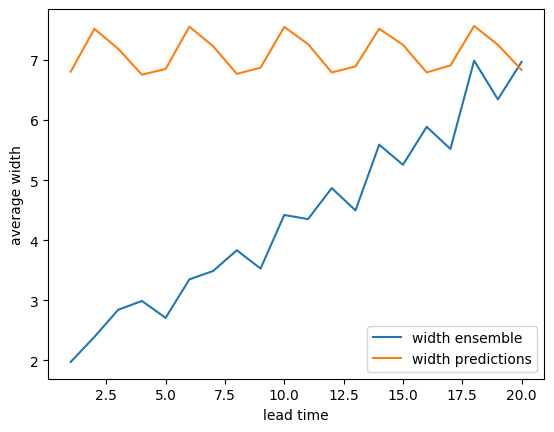

In [ ]:
# Width

plt.plot(x, width_ens, label = 'width ensemble')
plt.plot(x, width_pred, label = 'width predictions')
plt.legend()
plt.xlabel('lead time')
plt.ylabel('average width')
plt.show();

# CONCLUSION AND FURTHER WORK

There is probably a couple of things I could write about this project but I am out of time.

- The point forecast revealed that a simple linear layer was the best option, even for multiple features. Probably there was a linear relationship between the forecasts and the actual temperatures.

- Adding other features such as wind speed and total cloud cover may remove this linear relationship, so using non-linear layers caused improvements, but we also used 2 input heads and made it more complex, so I am not sure which changes caused this improvement.

- The probabilistic forecast was also quite straightforward, the feature engineering somewhat improved the model, but the best loss was recorded in experiment 1.

**FURTHER WORK**
- Experiment with an LSTM for the point forecasts
- Experiment with the rolling window forecasting. This is more related to real life problems.